# Preprocesamiento

## Definiciones

In [1]:
from newGeo.dtGeometry import *
from itertools import chain
import logging
# MAPPING DIGIS
def create_wire_position_mapping(df_geometry):
    mapping = {}
    for idx, row in df_geometry.iterrows():
        chamber_rawId = row['Chamber_rawId']
        superLayerNumber = row['SuperLayerNumber']
        layerNumber = row['LayerNumber']
        channels_total = row['Channels_total']
        wireFirst = row['WirePositions_FirstWire']
        wireLast = row['WirePositions_LastWire']
        layer = row['LayerNumber']

        # Create Wire object to get positions
        wire_obj = Wire(wireFirst, wireLast, channels_total, row['Layer_Local_z'])
        # Map wire numbers to positions
        for wire_idx, x_pos in enumerate(wire_obj.positions):
            wire_number = wire_idx + 1  # Assuming wire numbers start from 1
            key = (chamber_rawId, superLayerNumber, layerNumber, wire_number)
            mapping[key] = (x_pos, wire_obj.layer_y)

    return mapping

def explode_dataframe(df, list_columns):
    """Explota columnas con listas en filas separadas."""
    # Repetir indices segun la longitud de las listas
    lengths = df[list_columns[0]].apply(len)
    idx = df.index.repeat(lengths)

    # Explotar las columnas de listas
    exploded_data = {col: list(chain.from_iterable(df[col])) for col in list_columns}

    # Agregar las columnas que no son listas
    exploded_df = pd.DataFrame(exploded_data, index=idx)
    non_list_columns = df.columns.difference(list_columns)
    for col in non_list_columns:
        exploded_df[col] = df[col].repeat(lengths)

    return exploded_df.reset_index(drop=True)

def add_chamber_rawId_to_digis(df):
    """Agrega la columna chamber_rawId basada en wheel, station y sector."""
    chamber_rawIds = []
    for idx, row in df.iterrows():
        try:
            rawId = get_rawId(row['digi_wheel'], row['digi_station'], row['digi_sector'])
        except ValueError as e:
            logging.error(f"Error al calcular rawId en el indice {idx}: {e}")
            rawId = None
        chamber_rawIds.append(rawId)
    df['digi_chamber_rawId'] = chamber_rawIds
    return df

def map_digi_wires_to_positions(df, wire_position_mapping):
    """Mapea los wires a sus posiciones en x usando wire_position_mapping."""
    x_positions = []
    for idx, row in df.iterrows():
        key = (row['digi_chamber_rawId'], row['digi_superLayer'], row['digi_layer'], row['digi_wire'])
        x_pos = wire_position_mapping.get(key, None)  # Por defecto, None si no se encuentra la clave
        x_positions.append(x_pos)
    df['digi_x_pos'] = x_positions
    return df

def reconstruct_dataframe(df_original, df_flattened, list_columns, extra_columns):
    """
    Reconstruye el DataFrame original, agrupando las columnas calculadas en listas.

    Args:
    - df_original: DataFrame original con listas.
    - df_flattened: DataFrame aplanado despues de las explosiones y calculos.
    - list_columns: Columnas que originalmente estaban en formato de lista.
    - extra_columns: Nuevas columnas a agregar al DataFrame.

    Returns:
    - DataFrame reconstruido con las columnas adicionales.
    """
    # Crear indice auxiliar para asociar filas a las originales
    df_flattened["original_index"] = df_original.index.repeat(
        df_original[list_columns[0]].apply(len)
    )

    # Agrupar filas aplanadas segun el indice original
    grouped = df_flattened.groupby("original_index")

    # Agregar de vuelta las columnas originales y las nuevas
    for col in list_columns + extra_columns:
        df_original[col] = grouped[col].apply(list).reindex(df_original.index).tolist()

    return df_original

# MAPPING SEGMENTS
def add_chamber_rawId_to_segments(df):
    """Agrega la columna chamber_rawId basada en wheel, station y sector."""
    chamber_rawIds = []
    for idx, row in df.iterrows():
        try:
            rawId = get_rawId(row['seg_wheel'], row['seg_station'], row['seg_sector'])
        except ValueError as e:
            logging.error(f"Error al calcular rawId en el indice {idx}: {e}")
            rawId = None
        chamber_rawIds.append(rawId)
    df['seg_chamber_rawId'] = chamber_rawIds
    return df

def map_segments_wires_to_positions(df, wire_position_mapping):
    """Mapea los wires a sus posiciones en x usando wire_position_mapping."""
    x_positions = []
    for idx, row in df.iterrows():
        key = (row['seg_chamber_rawId'], row['seg_phiHits_superLayer'], row['seg_phiHits_layer'], row['seg_phiHits_wire'])  
        x_pos = wire_position_mapping.get(key, None)  # Por defecto, None si no se encuentra la clave
        x_positions.append(x_pos)
    df['seg_x_pos'] = x_positions
    return df

def reconstruct_dataframe_seg(df_original, df_flattened, list_columns, extra_columns):
    """
    Reconstruye el DataFrame original, agrupando las columnas calculadas en listas.

    Args:
    - df_original: DataFrame original con listas.
    - df_flattened: DataFrame aplanado despues de las explosiones y calculos.
    - list_columns: Columnas que originalmente estaban en formato de lista.
    - extra_columns: Nuevas columnas a agregar al DataFrame.

    Returns:
    - DataFrame reconstruido con las columnas adicionales.
    """
    # Crear indice auxiliar para asociar filas a las originales
    # Ajustar índice según las filas ya existentes en df_flattened
    df_flattened["original_index"] = df_original.index.repeat(
    df_original[list_columns_2[0]].apply(lambda x: sum(len(inner_list) for inner_list in x))
    )


    # Agrupar filas aplanadas segun el indice original
    grouped = df_flattened.groupby("original_index")

    # Agregar de vuelta las columnas originales y las nuevas
    for col in list_columns + extra_columns:
        df_original[col] = grouped[col].apply(list).reindex(df_original.index).tolist()

    return df_original

# RESTO DE DEFS

def convertir_a_lista(x):
    # Funcion para convertir Awkward Arrays a listas de Python
    if isinstance(x, (list, tuple, np.ndarray)):
        return list(x)
    return [x]  # En caso de que sea un valor escalar, lo convertimos en lista

## main

In [ ]:
import ROOT
import pandas as pd

# Definir la ruta del archivo ROOT y el nombre del arbol
#DTDPGNtuple_14_1_0_DYLL_M50_PU200_qcut0 (grande)
#DTDPGNtuple_12_4_2_Phase2Concentrator_Simulation_89
ruta_archivo_root = '../dtTuples/DTDPGNtuple_14_1_0_DYLL_M50_PU200_qcut0.root'
nombre_arbol = 'dtNtupleProducer/DTTREE'

# Abrir el archivo ROOT
archivo = ROOT.TFile.Open(ruta_archivo_root)
if not archivo or archivo.IsZombie():
    raise FileNotFoundError(f"No se pudo abrir el archivo ROOT en {ruta_archivo_root}")

# Obtener el arbol
arbol = archivo.Get(nombre_arbol)
if not arbol:
    raise ValueError(f"No se encontro el arbol '{nombre_arbol}' en el archivo ROOT.")

# Obtener el numero de eventos en el arbol
numero_eventos = arbol.GetEntries()
print(f"El arbol tiene {numero_eventos} eventos.")

In [ ]:

# Listas de ramas
ramas_event = ['event_eventNumber']
ramas_digis_numericas = ["digi_nDigis", "digi_wheel", "digi_sector", "digi_station", 
    "digi_superLayer", "digi_layer", "digi_wire", "digi_time"]
ramas_seg_numericas = [
    "seg_nSegments", "seg_wheel", "seg_sector", "seg_station", "seg_hasPhi", 
    "seg_hasZed", "seg_posLoc_x", "seg_posLoc_y", "seg_posLoc_z", 
    "seg_dirLoc_x", "seg_dirLoc_y", "seg_dirLoc_z", "seg_posLoc_x_SL1", 
    "seg_posLoc_x_SL3", "seg_posLoc_x_midPlane", "seg_posGlb_phi", 
    "seg_posGlb_eta", "seg_dirGlb_phi", "seg_dirGlb_eta", "seg_phi_t0", 
    "seg_phi_vDrift", "seg_phi_normChi2", "seg_phi_nHits", 
    "seg_z_normChi2", "seg_z_nHits"
]
ramas_seg_arrays = [
    'seg_phiHits_pos', 'seg_phiHits_posCh', 'seg_phiHits_posErr', 
    'seg_phiHits_side', 'seg_phiHits_wire', 'seg_phiHits_wirePos', 
    'seg_phiHits_layer', 'seg_phiHits_superLayer', 'seg_phiHits_time', 
    'seg_phiHits_timeCali'
]

ramas_a_extraer = ramas_event + ramas_digis_numericas + ramas_seg_numericas + ramas_seg_arrays


In [ ]:
# Inicializar diccionario para almacenar los datos
data = {rama: [] for rama in ramas_a_extraer}

# Obtener el numero de eventos en el arbol
numero_eventos = arbol.GetEntries()
print(f"El arbol tiene {numero_eventos} eventos.")


In [ ]:
from collections import defaultdict
import time

data = defaultdict(list)
min = 200000
max_eventos = 300000
start_total = time.time()

# Iterar sobre las entradas del arbol
for i, evento in enumerate(arbol):
    if i<= min:
        continue
    if i >= max_eventos:
        break  
    for rama in ramas_a_extraer:
        valor = getattr(evento, rama, None)
        
        if valor is None:
            data[rama].append(None)
            continue

        # Optimizacion: manejar TClonesArray
        if hasattr(valor, 'GetEntriesFast'):
            n_entries = valor.GetEntriesFast()  # Guardar numero de entradas
            valores = [
                [x for x in valor.At(i)] if hasattr(valor.At(i), '__len__') else valor.At(i)
                for i in range(n_entries)
            ]
            data[rama].append(valores)
        elif isinstance(valor, (ROOT.TVectorF, ROOT.TVectorD)):
            # Optimizacion: convertir directamente a lista
            data[rama].append(list(valor))
        elif isinstance(valor, (int, float)):
            # Escalar simple
            data[rama].append(valor)
        else:
            try:
                # Intentar convertir a lista si es iterable
                data[rama].append(list(valor))
            except TypeError:
                data[rama].append(valor)
    
    if i%10000==0:
        print(f"Evento {i+1}")

end_total = time.time()
print(f"Tiempo total: {end_total - start_total:.2f} segundos")
# Cerrar el archivo ROOT
archivo.Close()

In [ ]:
# Verificar que todas las ramas tienen la misma longitud
longitudes = {rama: len(val) for rama, val in data.items()}
print("Longitud de cada rama:")

for rama, longitud in longitudes.items():
    print(f"{rama}: {longitud}")

# Convertir a DataFrame
try:
    df = pd.DataFrame(data)
except ValueError as e:
    print("Error al crear el DataFrame:", e)
    for rama, longitud in longitudes.items():
        print(f"{rama}: {longitud}")
    raise

# Mostrar una vista previa del DataFrame
print("\nVista previa del DataFrame:")
df.head()

# Contar los hits en las ramas tipo array
for rama in ramas_seg_arrays:
    if rama in df.columns:
        df[f'{rama}_count'] = df[rama].apply(lambda x: len(x) if isinstance(x, list) else 0)

# Mostrar conteos
for rama in ramas_seg_arrays:
    if f'{rama}_count' in df.columns:
        print(f"\nNumero de hits por evento en '{rama}':")
        print(df[f'{rama}_count'].head())

# Guardar el DataFrame en un archivo CSV
#df.to_csv('data.csv', index=False)
#print('Data saved in data.csv')

In [ ]:
geometry_xml_path = "newGeo/DTGeometry.xml"

# Parse DT Geometry XML
print("\nParsing DT Geometry XML...")
df_geometry = parse_dtgeometry_xml(geometry_xml_path)

# Crear mapeo
wire_position_mapping = create_wire_position_mapping(df_geometry)

# Columnas con valores en listas
list_columns = ['digi_wheel', 'digi_sector', 'digi_station', 'digi_superLayer', 'digi_layer', 'digi_wire']

# Explotar el DataFrame para trabajar con cada digi individualmente
df_flattened = explode_dataframe(df, list_columns)

# Agregar la columna chamber_rawId
df_flattened = add_chamber_rawId_to_digis(df_flattened)

# Calcular las posiciones de los wires
df_flattened = map_digi_wires_to_positions(df_flattened, wire_position_mapping)

# Reconstruir el DataFrame original con la nueva columna
df = reconstruct_dataframe(df, df_flattened, list_columns, ['digi_x_pos'])

# Reordenar columnas para que digi_x_pos aparezca despues de digi_wire
columns = df.columns.tolist()
digi_wire_index = columns.index('digi_wire')
columns.insert(digi_wire_index + 1, columns.pop(columns.index('digi_x_pos')))
df = df[columns]

# Mostrar el DataFrame final 
df.head()


In [2]:
import pandas as pd
import ast
#df.to_csv(f'{max_eventos}_datos.csv')
#df = pd.read_csv("100000_datos.csv")

#df.to_json("300000_datos.json", orient="records", lines=True) #lo guardo en json q sino las listas se guardan como caracteres
df1 = pd.read_json("100000_datos.json", orient="records", lines=True)
df2 = pd.read_json("200000_datos.json", orient="records", lines=True)
df3 = pd.read_json("300000_datos.json", orient="records", lines=True)
df = pd.concat([df1, df2, df3])

In [ ]:
# Filtros 
# Solo los que tengan 1 segmento
df = df[df['seg_nSegments'] == 1]

# De los que quedan cogemos los que tengam 8 hits
df= df[df['seg_phi_nHits'].apply(lambda x: x == [8])]

# Para cuando queramos aumentar el numero de hits
#hits = {7, 8}
#df = df[df['seg_phi_nHits'].apply(lambda x: x[0] in hits)]

#df.to_csv('data_8hits_1seg.csv') #lo guardo por si acaso

In [4]:
# hacemos lo mismo para los segmentos
geometry_xml_path = "newGeo/DTGeometry.xml"

# Parse DT Geometry XML
print("\nParsing DT Geometry XML...")
df_geometry = parse_dtgeometry_xml(geometry_xml_path)

# Mapeo
wire_position_mapping = create_wire_position_mapping(df_geometry)

# Columnas con valores en listas
list_columns = ['seg_wheel', 'seg_sector', 'seg_station', 'seg_phiHits_superLayer', 'seg_phiHits_layer', 'seg_phiHits_wire']

# Explotar el DataFrame para trabajar con cada digi individualmente
df_flattened = explode_dataframe(df, list_columns)
list_columns_2 = ['seg_phiHits_superLayer', 'seg_phiHits_layer', 'seg_phiHits_wire']
df_flattened = explode_dataframe(df_flattened, list_columns_2)

# Agregar la columna chamber_rawId
df_flattened = add_chamber_rawId_to_segments(df_flattened)

# Calcular las posiciones de los wires
df_flattened = map_segments_wires_to_positions(df_flattened, wire_position_mapping)

# Reconstruir el DataFrame original con la nueva columna
df = reconstruct_dataframe_seg(df, df_flattened, list_columns, ['seg_x_pos'])

# Reordenar columnas para que digi_x_pos aparezca despues de digi_wire
columns = df.columns.tolist()
seg_wire_index = columns.index('seg_phiHits_wire')
columns.insert(seg_wire_index + 1, columns.pop(columns.index('seg_x_pos')))
df = df[columns]

# Mostrar el DataFrame final 
df.head()


Parsing DT Geometry XML...


,event_eventNumber,digi_nDigis,digi_wheel,digi_sector,digi_station,digi_superLayer,digi_layer,digi_wire,digi_x_pos,digi_time,...,seg_phiHits_pos_count,seg_phiHits_posCh_count,seg_phiHits_posErr_count,seg_phiHits_side_count,seg_phiHits_wire_count,seg_phiHits_wirePos_count,seg_phiHits_layer_count,seg_phiHits_superLayer_count,seg_phiHits_time_count,seg_phiHits_timeCali_count
5,27003,21,"[-1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -...","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 1, 1, 2, ...","[1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 3, 4, 2, ...","[28, 29, 28, 29, 40, 40, 40, 40, 28, 28, 28, 2...","[[11.0000059875, 13.7], [13.0999965714, 12.4],...","[646.875, 737.5, 658.59375, 730.46875, 802.343...",...,1,1,1,1,1,1,1,1,1,1
98,27103,27,"[-2, 1, 1, 2, 2, -2, -2, -2, -2, -2, -2, -2, -...","[2, 3, 3, 3, 3, 10, 10, 10, 10, 10, 10, 10, 10...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 3, 3, 2, 2, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, ...","[1, 3, 4, 2, 3, 1, 2, 3, 4, 1, 2, 3, 4, 1, 2, ...","[14, 19, 19, 28, 28, 32, 33, 32, 33, 51, 52, 5...","[[-47.7999981542, 13.7], [-25.700014375, -12.4...","[769.53125, 592.96875, 481.25, 999.21875, 755....",...,1,1,1,1,1,1,1,1,1,1
553,27555,43,"[-2, 2, 2, -2, -2, -2, -2, 2, 2, 2, 2, -2, 2, ...","[1, 1, 1, 2, 2, 2, 4, 5, 5, 5, 7, 9, 9, 9, 9, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 3, 3, 1, 3, 3, 2, 2, 2, 3, 1, 2, 1, 1, 1, ...","[4, 2, 2, 3, 3, 4, 1, 2, 3, 4, 2, 3, 1, 2, 3, ...","[41, 49, 50, 27, 28, 29, 20, 35, 35, 31, 17, 1...","[[67.7000059362, 9.79999], [98.1999942449, -11...","[695.3125, 658.59375, 590.625, 693.75, 835.156...",...,1,1,1,1,1,1,1,1,1,1
588,27588,28,"[2, 2, -1, -2, -2, -2, 2, 2, 2, 2, 2, 2, 2, 2,...","[2, 2, 3, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[2, 2, 3, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 3, ...","[3, 4, 3, 1, 2, 3, 1, 2, 3, 4, 1, 2, 3, 4, 1, ...","[25, 26, 34, 3, 3, 3, 38, 39, 38, 39, 9, 10, 9...","[[-16.7999965714, -7.04999], [-10.5, -8.34999]...","[732.03125, 733.59375, 511.71875, 761.71875, 5...",...,1,1,1,1,1,1,1,1,1,1
706,27705,29,"[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, -2, 2,...","[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 6, 6, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 1, 1, 1, ...","[1, 2, 3, 4, 1, 2, 3, 4, 1, 2, 3, 4, 4, 1, 1, ...","[10, 10, 10, 10, 51, 51, 51, 51, 10, 11, 10, 1...","[[-61.4000095375, 13.7], [-63.4999916735, 12.4...","[682.03125, 675.78125, 687.5, 681.25, 513.2812...",...,1,1,1,1,1,1,1,1,1,1


In [5]:
# Ramas relacionadas con 'digis'
ramas_digis = [
    "event_eventNumber",
    "digi_nDigis", "digi_wheel", "digi_sector", "digi_station", 
    "digi_superLayer", "digi_layer", "digi_wire", "digi_time", "digi_x_pos"
]

# Ramas relacionadas con 'segments' (seg)
ramas_segments = [
    "event_eventNumber",
    "seg_nSegments",
    "seg_wheel",
    "seg_sector",
    "seg_station",
    "seg_hasPhi",
    "seg_hasZed",
    "seg_posLoc_x",
    "seg_posLoc_y",
    "seg_posLoc_z",
    "seg_dirLoc_x",
    "seg_dirLoc_y",
    "seg_dirLoc_z",
    "seg_posLoc_x_SL1",
    "seg_posLoc_x_SL3",
    "seg_posLoc_x_midPlane",
    "seg_posGlb_phi",
    "seg_posGlb_eta",
    "seg_dirGlb_phi",
    "seg_dirGlb_eta",
    "seg_phi_t0",
    "seg_phi_vDrift",
    "seg_phi_normChi2",
    "seg_phi_nHits",
    "seg_z_normChi2",
    "seg_z_nHits",
    "seg_phiHits_wire",
    "seg_phiHits_layer",
    "seg_phiHits_superLayer",
    'seg_phiHits_time',
    'seg_x_pos'
]

# Combinar todas las ramas a extraer
ramas_a_extraer = ramas_digis + ramas_segments

In [6]:
# Extraer las ramas relacionadas con 'digis' en un DataFrame de pandas
df_digis = df[ramas_digis]

# Extraer las ramas relacionadas con 'segments' en otro DataFrame de pandas
df_segments = df[ramas_segments]

In [7]:
# Aplicar la conversion a todas las columnas de 'digis' que son listas ( excepto 'event_eventNumber' )  

for col in ramas_digis:
    df_digis.loc[:, col] = df_digis[col].apply(convertir_a_lista)

for col in ramas_segments:
    df_segments.loc[:, col] = df_segments[col].apply(convertir_a_lista)

/tmp/ipykernel_2731/3153974555.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[list([27003]) list([27103]) list([27555]) ... list([806799])
 list([806861]) list([806887])]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_digis.loc[:, col] = df_digis[col].apply(convertir_a_lista)
/tmp/ipykernel_2731/3153974555.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[list([21]) list([27]) list([43]) ... list([37]) list([22]) list([20])]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_digis.loc[:, col] = df_digis[col].apply(convertir_a_lista)
/tmp/ipykernel_2731/3153974555.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[list([27003]) list([27103]) list([27555]) ... list([806799])
 li

# Digis

In [176]:
# Definir las columnas relacionadas con 'digis' que seran aplanadas
columns_to_explode_digis = ['digi_superLayer', 'digi_layer', 'digi_wire', 'digi_time', 'digi_wheel', 'digi_sector', 'digi_station', 'digi_x_pos']


def verificar_longitudes(row, cols):
    # Funcion para verificar si todas las listas tienen la misma longitud en una fila
    lengths = [len(row[col]) for col in cols]
    return len(set(lengths)) == 1  # True si todas las longitudes son iguales

# Aplicar la funcion a cada fila
# Asignar la columna 'same_length' usando .loc
df_digis['same_length'] = df_digis.apply(lambda row: verificar_longitudes(row, columns_to_explode_digis), axis=1)

# Verificar cuantas filas cumplen la condicion
print("Numero de filas con listas de la misma longitud en 'digis':")
print(df_digis['same_length'].value_counts())

# Filtrar solo las filas que cumplen la condicion
df_digis = df_digis[df_digis['same_length']]

# Eliminar la columna auxiliar
df_digis = df_digis.drop(columns=['same_length'])


Numero de filas con listas de la misma longitud en 'digis':
same_length
True    2319
Name: count, dtype: int64


In [177]:
# ahora vamos a aplanar las columnas de 'digis' que contienen listas
columns_to_explode_digis = [
    'digi_superLayer', 'digi_layer', 'digi_wire', 
    'digi_time', 'digi_wheel', 'digi_sector', 'digi_station', 'digi_x_pos'
]

df_digis_exploded = df_digis.explode(columns_to_explode_digis)

# Renombrar las columnas a nombres mas cortos
df_digis_exploded = df_digis_exploded.rename(columns={
    "event_eventNumber": "eventNumber",
    "digi_superLayer": "superLayer",
    "digi_layer": "layer",
    "digi_wire": "wire",
    "digi_time": "time",
    "digi_wheel": "wheel",
    "digi_sector": "sector",
    "digi_station": "station",
    "digi_x_pos": "x_pos"
})

# Convertir 'event_eventNumber' a entero, ya que antes era una lista
df_digis_exploded['eventNumber'] = df_digis_exploded['eventNumber'].apply(lambda x: x if isinstance(x, (int, str)) else x[0])

# Eliminar la columna 'digi_nDigis' ya que no es necesaria, puesto que cuenta el numero de digis en cada evento, no de cada estacion
df_digis_exploded = df_digis_exploded.drop(columns=['digi_nDigis'])

# ELiminamos los digis de la superLayer 2, ya que no son necesarios y pueden influir en los resultados
df_digis_exploded = df_digis_exploded[df_digis_exploded['superLayer'] != 2]
df_digis_exploded.head()

,eventNumber,wheel,sector,station,superLayer,layer,wire,time,x_pos
5,27003,-1,2,1,1,1,28,646.875,"[11.0000059875, 13.7]"
5,27003,-1,2,1,1,2,29,737.5,"[13.0999965714, 12.4]"
5,27003,-1,2,1,1,3,28,658.59375,"[10.9999857687, 11.1]"
5,27003,-1,2,1,1,4,29,730.46875,"[17.2999948426, 9.8]"
5,27003,-1,2,1,3,1,28,732.8125,"[13.0999874375, -9.80001]"


In [178]:
#quitar esto no me hace falta

'''# voy a normalizar el tiempo lo primero de todo
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_digis_exploded["tiempo_normalizado"] = scaler.fit_transform(df_digis_exploded[['time']])

df_digis_exploded.head()'''

'# voy a normalizar el tiempo lo primero de todo\nfrom sklearn.preprocessing import StandardScaler\n\nscaler = StandardScaler()\ndf_digis_exploded["tiempo_normalizado"] = scaler.fit_transform(df_digis_exploded[[\'time\']])\n\ndf_digis_exploded.head()'

In [179]:
#agrupar digis para hacer los grafos
df_digis_nodos = df_digis_exploded.groupby(
    ['eventNumber', 'wheel', 'sector', 'station']
).agg({
    'wire': list,
    'layer': list,
    'time': list,
    'x_pos': list,
    'superLayer': list,
    'time': list
}).reset_index()
df_digis_nodos['n_digis'] = df_digis_nodos['wire'].apply(len)
df_digis_nodos.head()

,eventNumber,wheel,sector,station,wire,layer,time,x_pos,superLayer,n_digis
0,96,-2,3,1,"[22, 23, 23]","[1, 3, 4]","[786.71875, 815.625, 471.875]","[[-14.1999979812, 13.7], [-9.9999938375, 11.1]...","[1, 1, 1]",3
1,96,-2,9,1,"[25, 25, 25, 25, 23, 24, 23, 24]","[1, 2, 3, 4, 1, 2, 3, 4]","[700.78125, 609.375, 778.125, 534.375, 673.437...","[[-1.59999855, 13.7], [-3.7000017959, 12.4], [...","[1, 1, 1, 1, 3, 3, 3, 3]",8
2,96,-2,11,2,"[12, 12]","[3, 4]","[646.875, 630.46875]","[[-73.249983322, 11.1], [-71.1499877414, 9.800...","[1, 1]",2
3,96,-1,7,2,[53],[4],[619.53125],"[[96.8499960345, -13.7]]",[3],1
4,96,-1,10,1,[29],[1],[886.71875],"[[17.3000038333, -9.80002]]",[3],1


In [ ]:
#añadir ruidos
import numpy as np
import pandas as pd

def ruido_wire(wire_list, num_extra=4, max_offset=10):
    wire_list = list(wire_list)  # Copia 
    extra_wires = []
    
    for _ in range(num_extra): 
        wire = np.random.choice(wire_list)  # Escogemos un wire 
        noise = np.random.randint(-max_offset, max_offset + 1)  # ruido
        extra_wires.append(wire + noise)
    return wire_list + extra_wires  

def ruido_layer(layer_list, num_extra=3):
    layer_list = list(layer_list)
    extra_layers = []
    
    for _ in range(num_extra):
        layers = [1, 2, 3, 4]
        extra_layers.append(np.random.choice(layers)) 
    return layer_list + extra_layers

def ruido_time(time_list, num_extra=3, ruido_std=0.05):
    time_list = np.array(time_list)  
    extra_times = np.random.choice(time_list, num_extra) + np.random.normal(0, ruido_std, size=num_extra)

    return (time_list).tolist() + extra_times.tolist()

def ruido_sl(superlayer_list, num_extra=3):
    superlayer_list = list(superlayer_list)
    extra_superlayers = []

    for _ in range(num_extra):
        superlayers = [1, 3]
        extra_superlayers.append(np.random.choice(superlayers))
    return superlayer_list + extra_superlayers

# Aplicamos las funciones a cada columna relevante
num_extra = 8
df_digis_nodos["wire_con_ruido"] = df_digis_nodos["wire"].apply(lambda x: ruido_wire(x, num_extra=num_extra, max_offset=2))
df_digis_nodos["layer_con_ruido"] = df_digis_nodos["layer"].apply(lambda x: ruido_layer(x, num_extra=num_extra))
df_digis_nodos["time_con_ruido"] = df_digis_nodos["time"].apply(lambda x: ruido_time(x, num_extra=num_extra, ruido_std=0.05))
df_digis_nodos["superlayer_con_ruido"] = df_digis_nodos["superLayer"].apply(lambda x: ruido_sl(x, num_extra=num_extra))

df_digis_nodos.head()


,eventNumber,wheel,sector,station,wire,layer,time,x_pos,superLayer,n_digis,wire_con_ruido,layer_con_ruido,time_con_ruido,superlayer_con_ruido
0,96,-2,3,1,"[22, 23, 23]","[1, 3, 4]","[786.71875, 815.625, 471.875]","[[-14.1999979812, 13.7], [-9.9999938375, 11.1]...","[1, 1, 1]",3,"[22, 23, 23, 24, 21, 22, 25, 21, 24, 24, 22]","[1, 3, 4, 1, 1, 1, 3, 2, 4, 1, 4]","[786.71875, 815.625, 471.875, 471.864487965632...","[1, 1, 1, 1, 3, 1, 3, 1, 1, 1, 3]"
1,96,-2,9,1,"[25, 25, 25, 25, 23, 24, 23, 24]","[1, 2, 3, 4, 1, 2, 3, 4]","[700.78125, 609.375, 778.125, 534.375, 673.437...","[[-1.59999855, 13.7], [-3.7000017959, 12.4], [...","[1, 1, 1, 1, 3, 3, 3, 3]",8,"[25, 25, 25, 25, 23, 24, 23, 24, 22, 22, 25, 2...","[1, 2, 3, 4, 1, 2, 3, 4, 2, 3, 4, 4, 2, 3, 3, 4]","[700.78125, 609.375, 778.125, 534.375, 673.437...","[1, 1, 1, 1, 3, 3, 3, 3, 3, 1, 3, 1, 1, 1, 1, 3]"
2,96,-2,11,2,"[12, 12]","[3, 4]","[646.875, 630.46875]","[[-73.249983322, 11.1], [-71.1499877414, 9.800...","[1, 1]",2,"[12, 12, 10, 11, 10, 11, 14, 13, 14, 10]","[3, 4, 4, 4, 2, 3, 2, 3, 1, 2]","[646.875, 630.46875, 646.7768978487999, 630.43...","[1, 1, 1, 1, 1, 1, 3, 1, 1, 3]"
3,96,-1,7,2,[53],[4],[619.53125],"[[96.8499960345, -13.7]]",[3],1,"[53, 53, 54, 51, 54, 53, 53, 54, 54]","[4, 4, 2, 3, 3, 2, 3, 4, 4]","[619.53125, 619.5576525278138, 619.41226471502...","[3, 1, 1, 1, 3, 3, 1, 3, 3]"
4,96,-1,10,1,[29],[1],[886.71875],"[[17.3000038333, -9.80002]]",[3],1,"[29, 30, 30, 31, 27, 31, 27, 31, 27]","[1, 4, 4, 1, 4, 4, 3, 2, 1]","[886.71875, 886.7243735548954, 886.71466232612...","[3, 3, 1, 1, 3, 3, 1, 3, 1]"


In [181]:
#df_digis_nodos_2 = df_digis_nodos[df_digis_nodos['wire'].apply(lambda x: len(x) <= 10)]

# Segments

In [182]:
# Se construyen ahora la verdades con la parte de segments
# En concreto nos interesan las columnas seg_phiHits_wire y seg_phiHits_superlayer
# Creamos los grafos de la misma manera, primero aplanamos los datos

# Eliminar columnas de segmentos con las que no vamos a trabajar
columnas_a_eliminar = [col for col in df_segments.columns if col not in ['event_eventNumber', 'seg_wheel', 'seg_sector', 'seg_station',"seg_phiHits_wire","seg_phiHits_layer","seg_phiHits_superLayer","seg_x_pos", 'seg_phi_nHits', 'seg_phiHits_time']]

df_segments_filtered = df_segments.drop(columns=columnas_a_eliminar)

# Nos aseguramos de que 'event_eventNumber' sea un escalar, ya que antes convertimos todas las columnas a listas
df_segments_filtered['event_eventNumber'] = df_segments['event_eventNumber'].str[0]
df_segments_filtered = df_segments_filtered.explode('seg_phiHits_time')
df_segments_filtered = df_segments_filtered[df_segments_filtered['seg_phiHits_wire'].apply(lambda x: len(x) == 8)] #algo pasa que hay algunos que son mayores que 8 a pesar de q los hemos filtrado ????
df_segments_filtered.head()

,event_eventNumber,seg_wheel,seg_sector,seg_station,seg_phi_nHits,seg_phiHits_wire,seg_phiHits_layer,seg_phiHits_superLayer,seg_phiHits_time,seg_x_pos
5,27003,"[-1, -1, -1, -1, -1, -1, -1, -1]","[2, 2, 2, 2, 2, 2, 2, 2]","[1, 1, 1, 1, 1, 1, 1, 1]",[8],"[28.0, 29.0, 28.0, 29.0, 28.0, 28.0, 28.0, 28.0]","[1.0, 2.0, 3.0, 4.0, 1.0, 2.0, 3.0, 4.0]","[1.0, 1.0, 1.0, 1.0, 3.0, 3.0, 3.0, 3.0]","[646.875, 737.5, 658.59375, 730.46875, 732.812...","[(11.00000598749999, 13.7), (13.09999657142857..."
98,27103,"[-2, -2, -2, -2, -2, -2, -2, -2]","[10, 10, 10, 10, 10, 10, 10, 10]","[1, 1, 1, 1, 1, 1, 1, 1]",[8],"[32.0, 33.0, 32.0, 33.0, 37.0, 37.0, 37.0, 38.0]","[1.0, 2.0, 3.0, 4.0, 1.0, 2.0, 3.0, 4.0]","[1.0, 1.0, 1.0, 1.0, 3.0, 3.0, 3.0, 3.0]","[638.28125, 804.6875, 781.25, 607.03125, 717.1...","[(27.80000012291667, 13.7), (29.9000071632653,..."
553,27555,"[2, 2, 2, 2, 2, 2, 2, 2]","[9, 9, 9, 9, 9, 9, 9, 9]","[1, 1, 1, 1, 1, 1, 1, 1]",[8],"[29.0, 29.0, 29.0, 29.0, 27.0, 27.0, 26.0, 27.0]","[1.0, 2.0, 3.0, 4.0, 1.0, 2.0, 3.0, 4.0]","[1.0, 1.0, 1.0, 1.0, 3.0, 3.0, 3.0, 3.0]","[553.125, 828.90625, 729.6875, 564.0625, 785.1...","[(18.399997791666678, 13.7), (16.3000005714285..."
588,27588,"[2, 2, 2, 2, 2, 2, 2, 2]","[5, 5, 5, 5, 5, 5, 5, 5]","[1, 1, 1, 1, 1, 1, 1, 1]",[8],"[38.0, 39.0, 38.0, 39.0, 40.0, 40.0, 40.0, 40.0]","[1.0, 2.0, 3.0, 4.0, 1.0, 2.0, 3.0, 4.0]","[1.0, 1.0, 1.0, 1.0, 3.0, 3.0, 3.0, 3.0]","[716.40625, 562.5, 767.1875, 517.96875, 840.62...","[(56.19999874583331, 13.7), (58.29999648979593..."
706,27705,"[2, 2, 2, 2, 2, 2, 2, 2]","[2, 2, 2, 2, 2, 2, 2, 2]","[1, 1, 1, 1, 1, 1, 1, 1]",[8],"[10.0, 10.0, 10.0, 10.0, 10.0, 11.0, 10.0, 11.0]","[1.0, 2.0, 3.0, 4.0, 1.0, 2.0, 3.0, 4.0]","[1.0, 1.0, 1.0, 1.0, 3.0, 3.0, 3.0, 3.0]","[682.03125, 675.78125, 687.5, 681.25, 671.0937...","[(-61.400009537500004, 13.7), (-63.49999167346..."


### Filtros

In [183]:
#dejo esto comentado de momento pq trabajamos con nsegments=1
# Primero filtro los nans
#df_segments_filtered_2 = df_segments_filtered[~df_segments_filtered.apply(lambda row: any(pd.isna(item) or len(col) == 0 for col in row if isinstance(col, list) for item in (col if len(col) > 0 else [None])), axis=1)]

# FILTRO : filtrar de cada elemento de seg_phi_nhits todos aquellos elementos de 8 hits
'''def filtrar_segmentos_8hits(df, split = 'seg_phi_nHits', id =  'event_eventNumber' ):
    split_lens = df[split].apply(len)
    ids = df[id].repeat(split_lens).reset_index(drop=True)
    split_values = np.concatenate(df[split].values)
    
    # Aplicar la segmentación a todas las columnas excepto Split
    expanded_data = {id: ids, split: split_values}
    for col in df.columns:
        if col not in [id, split]:
            expanded_data[col] = [segment for d, s in zip(df[col], df[split]) for segment in np.split(d, np.cumsum(s)[:-1])]

    return pd.DataFrame(expanded_data)

df_segments_filtered_3 = filtrar_segmentos_8hits(df_segments_filtered_2)

# ahora drop de los que no sean 8
df_segments_filtered_4 = df_segments_filtered_3[df_segments_filtered_3['seg_phi_nHits'] == 8]'''

"def filtrar_segmentos_8hits(df, split = 'seg_phi_nHits', id =  'event_eventNumber' ):\n    split_lens = df[split].apply(len)\n    ids = df[id].repeat(split_lens).reset_index(drop=True)\n    split_values = np.concatenate(df[split].values)\n    \n    # Aplicar la segmentación a todas las columnas excepto Split\n    expanded_data = {id: ids, split: split_values}\n    for col in df.columns:\n        if col not in [id, split]:\n            expanded_data[col] = [segment for d, s in zip(df[col], df[split]) for segment in np.split(d, np.cumsum(s)[:-1])]\n\n    return pd.DataFrame(expanded_data)\n\ndf_segments_filtered_3 = filtrar_segmentos_8hits(df_segments_filtered_2)\n\n# ahora drop de los que no sean 8\ndf_segments_filtered_4 = df_segments_filtered_3[df_segments_filtered_3['seg_phi_nHits'] == 8]"

In [184]:

# ahora vamos a aplanar las columnas de 'segments' que contienen listas
columns_to_explode_segments = [
    "seg_phiHits_superLayer", "seg_phiHits_layer", "seg_phiHits_wire", 
    'seg_wheel', 'seg_sector', 'seg_station','seg_x_pos', 'seg_phiHits_time'
]
df_segments_exploded = df_segments_filtered.explode(columns_to_explode_segments)

# Renombrar las columnas a nombres mas cortos
df_segments_exploded = df_segments_exploded.rename(columns={
    "event_eventNumber": "eventNumber",
    "seg_phiHits_superLayer": "superLayer",
    "seg_phiHits_layer": "layer",
    "seg_phiHits_wire": "wire",
    'seg_wheel': "wheel",
    'seg_sector': "sector",
    'seg_station': "station",
    "seg_x_pos": "x_pos",
    'seg_nSegments': 'nSegments',
    'seg_phiHits_time': 'time'
})

df_segments_exploded.head()

,eventNumber,wheel,sector,station,seg_phi_nHits,wire,layer,superLayer,time,x_pos
5,27003,-1,2,1,[8],28.0,1.0,1.0,646.875,"(11.00000598749999, 13.7)"
5,27003,-1,2,1,[8],29.0,2.0,1.0,737.5,"(13.099996571428576, 12.4)"
5,27003,-1,2,1,[8],28.0,3.0,1.0,658.59375,"(10.99998576874998, 11.1)"
5,27003,-1,2,1,[8],29.0,4.0,1.0,730.46875,"(17.299994842553176, 9.8)"
5,27003,-1,2,1,[8],28.0,1.0,3.0,732.8125,"(13.099987437500005, -9.80001)"


In [185]:
# hay que eliminar las filas que tienen listas vacias en wire, layer y superlayer puesto que estas pertenecen a la superlayer 2
# Identificar y eliminar filas donde las columnas tienen listas vacias
columnas_a_revisar = ["wire", 'layer', 'superLayer']  # Lista de columnas que queremos revisar
df_segments_exploded_limpio = df_segments_exploded[~df_segments_exploded[columnas_a_revisar]
    .apply(lambda col: col.apply(lambda x: isinstance(x, list) and len(x) == 0))
    .any(axis=1)
]

# Eliminar filas con nans
df_segments_exploded_limpio = df_segments_exploded_limpio.dropna()

# Ahora vamos a agrupar los digis por evento y estacion
df_segments_nodos = df_segments_exploded_limpio.groupby(
    ['eventNumber', 'wheel', 'sector', 'station']
).agg({
    'layer': list,
    'wire': list,
    'x_pos': list,
    'superLayer': list,
    'time': list
}).reset_index()

df_segments_nodos = df_segments_nodos[df_segments_nodos['superLayer'] != 2]
df_segments_nodos.head(10)

,eventNumber,wheel,sector,station,layer,wire,x_pos,superLayer,time
0,96,-2,9,1,"[1.0, 2.0, 3.0, 4.0, 1.0, 2.0, 3.0, 4.0]","[25.0, 25.0, 25.0, 25.0, 23.0, 24.0, 23.0, 24.0]","[(-1.5999985499999951, 13.7), (-3.700001795918...","[1.0, 1.0, 1.0, 1.0, 3.0, 3.0, 3.0, 3.0]","[700.78125, 609.375, 778.125, 534.375, 673.437..."
1,330,-2,6,2,"[1.0, 2.0, 3.0, 4.0, 1.0, 2.0, 3.0, 4.0]","[12.0, 13.0, 12.0, 13.0, 13.0, 13.0, 13.0, 13.0]","[(-73.25000518965517, 13.7), (-71.150007067796...","[1.0, 1.0, 1.0, 1.0, 3.0, 3.0, 3.0, 3.0]","[614.0625, 723.4375, 567.1875, 780.46875, 709...."
2,404,2,9,1,"[1.0, 2.0, 3.0, 4.0, 1.0, 2.0, 3.0, 4.0]","[21.0, 22.0, 21.0, 21.0, 20.0, 20.0, 19.0, 20.0]","[(-15.20000069166666, 13.7), (-13.099996571428...","[1.0, 1.0, 1.0, 1.0, 3.0, 3.0, 3.0, 3.0]","[643.75, 855.46875, 537.5, 796.875, 730.46875,..."
3,408,-1,4,1,"[1.0, 2.0, 3.0, 4.0, 1.0, 2.0, 3.0, 4.0]","[5.0, 5.0, 5.0, 5.0, 3.0, 4.0, 3.0, 4.0]","[(-85.59999475833334, 13.7), (-87.699985979591...","[1.0, 1.0, 1.0, 1.0, 3.0, 3.0, 3.0, 3.0]","[560.15625, 790.625, 658.59375, 680.46875, 704..."
4,538,-2,1,1,"[1.0, 2.0, 3.0, 4.0, 1.0, 2.0, 3.0, 4.0]","[20.0, 21.0, 20.0, 21.0, 20.0, 20.0, 20.0, 20.0]","[(-22.599997602083334, 13.7), (-20.49998989795...","[1.0, 1.0, 1.0, 1.0, 3.0, 3.0, 3.0, 3.0]","[749.21875, 578.90625, 724.21875, 598.4375, 77..."
5,579,-2,4,2,"[1.0, 2.0, 3.0, 4.0, 1.0, 2.0, 3.0, 4.0]","[5.0, 6.0, 5.0, 5.0, 3.0, 4.0, 3.0, 3.0]","[(-102.6499901724138, 13.7), (-100.54999610169...","[1.0, 1.0, 1.0, 1.0, 3.0, 3.0, 3.0, 3.0]","[891.40625, 674.21875, 619.53125, 879.6875, 77..."
6,676,1,3,1,"[1.0, 2.0, 3.0, 4.0, 1.0, 2.0, 3.0, 4.0]","[33.0, 33.0, 33.0, 33.0, 31.0, 32.0, 31.0, 32.0]","[(35.19999703333335, 13.7), (33.09997414285712...","[1.0, 1.0, 1.0, 1.0, 3.0, 3.0, 3.0, 3.0]","[730.46875, 709.375, 885.9375, 576.5625, 845.3..."
7,880,-2,5,1,"[1.0, 2.0, 3.0, 4.0, 1.0, 2.0, 3.0, 4.0]","[13.0, 13.0, 13.0, 13.0, 11.0, 12.0, 11.0, 11.0]","[(-51.99999845000001, 13.7), (-54.099996897959...","[1.0, 1.0, 1.0, 1.0, 3.0, 3.0, 3.0, 3.0]","[629.6875, 720.3125, 728.125, 623.4375, 636.71..."
8,929,-2,1,1,"[1.0, 2.0, 3.0, 4.0, 1.0, 2.0, 3.0, 4.0]","[19.0, 20.0, 19.0, 20.0, 17.0, 18.0, 17.0, 17.0]","[(-26.79999741249999, 13.7), (-24.699989653061...","[1.0, 1.0, 1.0, 1.0, 3.0, 3.0, 3.0, 3.0]","[751.5625, 676.5625, 595.3125, 821.875, 672.65..."
9,9038,-2,2,1,"[1.0, 2.0, 3.0, 4.0, 1.0, 2.0, 3.0, 4.0]","[24.0, 24.0, 24.0, 24.0, 24.0, 24.0, 24.0, 24.0]","[(-5.799995195833333, 13.7), (-7.9000013877550...","[1.0, 1.0, 1.0, 1.0, 3.0, 3.0, 3.0, 3.0]","[607.8125, 869.53125, 584.375, 892.96875, 751...."


# Grafos

## Definiciones

In [186]:
import torch
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx

def nodos_posicion(row):  
    # Esta funcion crea las coordenadas (x,y) de los nodos 
    wheel, sector, station = row['wheel'], row['sector'], row['station']    
    #datos = { 'digi_layer': row['layer_df1'],'digi_wire': row['wire_df1'],'digi_superLayer': row['superLayer_df1']}
    datos = { 'digi_layer': row['layer_con_ruido'],'digi_wire': row['wire_con_ruido'],'digi_superLayer': row['superlayer_con_ruido']}

    # Crear un DataFrame a partir del diccionario
    df_nodos = pd.DataFrame(datos).assign(digi_wheel=wheel, digi_sector=sector, digi_station=station)
    # Agregar la columna chamber_rawId
    df_nodos= add_chamber_rawId_to_digis(df_nodos)
    # Calcular las posiciones de los wires
    df_nodos = map_digi_wires_to_positions(df_nodos, wire_position_mapping)
    df_nodos[['x_pos', 'y_pos']] = pd.DataFrame(df_nodos['digi_x_pos'].tolist(), index=df_nodos.index) #en digi_x_pos hay tuplas con posiciones (x,y), las separo
    
    return df_nodos

def distancia_euc(nodo_i, nodo_j):
    nodo_i = torch.tensor(nodo_i, dtype=torch.float)
    nodo_j = torch.tensor(nodo_j, dtype=torch.float)    
    return torch.sqrt((nodo_i[0] - nodo_j[0])**2 + (nodo_i[1] - nodo_j[1])**2)# distancia euclidiana

def calcular_diferencia_layer(layer_i, layer_j):
    layer_i = torch.tensor(layer_i, dtype=torch.float)
    layer_j = torch.tensor(layer_j, dtype=torch.float)
    return abs(layer_i - layer_j) 

def calcular_diferencia_wire(wire_i, wire_j):
    wire_i = torch.tensor(wire_i, dtype=torch.float)
    wire_j = torch.tensor(wire_j, dtype=torch.float)
    return abs(wire_i - wire_j)  

def calcular_diferencia_superlayer(sl_i, sl_j):
    sl_i = torch.tensor(sl_i, dtype=torch.float)
    sl_j = torch.tensor(sl_j, dtype=torch.float)
    return abs(sl_i - sl_j) 

def angulo(nodo_i, nodo_j):
    nodo_i = torch.tensor(nodo_i, dtype=torch.float)
    x1, y1 = nodo_i[0], nodo_i[1]
    nodo_j = torch.tensor(nodo_j, dtype=torch.float)  
    x2, y2 = nodo_j[0], nodo_j[1] 
    return torch.atan2(y2 - y1, x2 - x1)

    
def generar_arista(primer_nodo, segundo_nodo, nodo_indices, distancia, angulito, dif_layer, dif_wire, dif_sl,angulos, edge_index, distancias, dif_layers, dif_wires, dif_sls, vecinos): 
    idx_i = nodo_indices[primer_nodo]
    idx_j = nodo_indices[segundo_nodo]           
    if (idx_i, idx_j) not in edge_index and (idx_j, idx_i) not in edge_index: #comprobar que no sea ya una arista
        edge_index.append((idx_i, idx_j))
        distancias.append(distancia)
        dif_layers.append(dif_layer)
        dif_wires.append(dif_wire)
        dif_sls.append(dif_sl)
        angulos.append(angulito)
        vecinos.add(primer_nodo)


def dibujar_grafo(data):
    # Convertir PyTorch a NetworkX
    G = to_networkx(data,  node_attrs=["x"], to_undirected=True)
    
    # Obtener posiciones de los nodos
    pos = {i: (data.x[i, 0].item(), data.x[i, 1].item()) for i in range(data.num_nodes)}
    
    # Obtener etiquetas de los nodos basadas en sus valores de x
    #labels = {i: f"{round(data.x[i,0].tolist())}" for i in range(data.num_nodes)}
    
    # Dibujar el grafo
    plt.figure(figsize=(8, 6))
    nx.draw_networkx_edges(G, pos, alpha=0.5, edge_color="gray")
    nx.draw_networkx_nodes(G, pos, node_size=300)
    #nx.draw_networkx_labels(G, pos, labels=labels, font_size=8, font_color="black")
    nx.draw_networkx_labels(G, pos, font_size=8, font_color="black")
    plt.title("Visualización del Grafo")
    plt.axis("off")
    plt.show()

## Main

In [187]:
from itertools import zip_longest
df1 = df_digis_nodos
df2 = df_segments_nodos

# Columnas para la comparacion
comparison_columns = ["eventNumber", "wheel", "sector", "station"]

# Unir los DataFrames
merged_df = pd.merge(df1, df2, on=comparison_columns, suffixes=('_df1', '_df2'))

# Funcion para comparar listas con longitudes diferentes
def compare_lists(list1, list2):
    return [x == y if x is not None and y is not None else False for x, y in zip_longest(list1, list2)]

# comparo las columnas 'wire' y 'layer' esto luego no sirve para nada pero para visualizar los q son correctos de los que no
merged_df['wire_comparison'] = merged_df.apply(lambda row: compare_lists(row['wire_df1'], row['wire_df2']), axis=1)
merged_df['layer_comparison'] = merged_df.apply(lambda row: compare_lists(row['layer_df1'], row['layer_df2']), axis=1)

# Seleccionar solo las columnas de interes
merged_df['superlayer_comparison'] = merged_df.apply(lambda row: compare_lists(row['superLayer_df1'], row['superLayer_df2']), axis=1)
df_verdad = merged_df[['wire_comparison', 'layer_comparison', 'superlayer_comparison']]
df_digis_nodos = merged_df[['eventNumber', 'wheel', 'sector', 'station', 'wire_df1', 'layer_df1','x_pos_df1','superLayer_df1', 'time_df1' ,'wire_con_ruido', 'layer_con_ruido', 'superlayer_con_ruido', 'time_con_ruido']]#tomamos los que tienen ruido
df_segments_nodos = merged_df[['eventNumber', 'wheel', 'sector', 'station', 'wire_df2', 'layer_df2','x_pos_df2','superLayer_df2','time_df2']]


In [188]:
import itertools
from itertools import zip_longest
from torch_geometric.data import Data

def crear_grafo_con_posiciones(row, row_verdad, imprimir_nodos = False, ruido = False):  
    # Obtener nodos con coordenadas
    nodos_posicion_df = nodos_posicion(row)
    #nodos = list(zip(nodos_posicion_df['x_pos'], nodos_posicion_df['y_pos'], nodos_posicion_df['digi_superLayer'],row['wire_df1'], row['layer_df1'], row['time']))
    #nodos = list(zip(nodos_posicion_df['x_pos'], nodos_posicion_df['y_pos'], nodos_posicion_df['digi_superLayer'],row['wire_df1'], row['layer_df1']))
    
    if ruido:
        nodos = list(zip(nodos_posicion_df['x_pos'], nodos_posicion_df['y_pos'], nodos_posicion_df['digi_superLayer'],row['wire_con_ruido'], row['layer_con_ruido'], row['time_con_ruido']))
        nodos_digis = list(zip(row['wire_con_ruido'], row['layer_con_ruido'], row['superlayer_con_ruido'], row['time_con_ruido']))
    else:
        nodos = list(zip(nodos_posicion_df['x_pos'], nodos_posicion_df['y_pos'], nodos_posicion_df['digi_superLayer'],row['wire_df1'], row['layer_df1'], row['time_df1']))
        nodos_digis = list(zip(row['wire_df1'], row['layer_df1'], row['superLayer_df1'], row['time_df1'])) #creo esta lista para luego poder compararla con la de nodos_verdad

   
    # Datos del dataset
    # FALTA METER EL TIME
    nodos_verdad = list(zip(row_verdad['wire_df2'], row_verdad['layer_df2'], row_verdad['superLayer_df2'], row_verdad['time_df2']))
    # Indices de nodos
    nodo_indices = {nodo: idx for idx, nodo in enumerate(nodos_digis)}

    # Generar aristas
    edge_index = []
    primeros_vecinos = set()
    #segundos_vecinos = set()
    #terceros_vecinos = set()
    distancias = []
    dif_layers = []
    dif_wires = []
    dif_sls = []
    angulos = []
        
    for i, j in itertools.combinations(range(len(nodos)), 2):
        x_pos_i, y_pos_i, sl_i, wire_i, layer_i, time_i = nodos[i]
        x_pos_j, y_pos_j, sl_j, wire_j, layer_j, time_j  = nodos[j] 
        distancia = distancia_euc(nodos[i], nodos[j])
        angulito = angulo(nodos[i], nodos[j])
        dif_layer = calcular_diferencia_layer(layer_i, layer_j)
        dif_wire = calcular_diferencia_wire(wire_i, wire_j)
        dif_sl = calcular_diferencia_superlayer(sl_i, sl_j)

        # Conexiones dentro del mismo superlayer
        if sl_i == sl_j:
            if abs(layer_i - layer_j) == 1 and abs(wire_i - wire_j) <= 1:  
                generar_arista(nodos_digis[i], nodos_digis[j], nodo_indices, distancia, angulito, dif_layer, dif_wire, dif_sl, angulos ,edge_index, distancias, dif_layers, dif_wires, dif_sls, primeros_vecinos)

            #lo siguiente esta comentado pq de momento solo primeros vecinos
            '''elif nodos_digis[i] not in primeros_vecinos and layer_i not in (3, 4):
                if abs(layer_i - layer_j) == 2 and abs(wire_i - wire_j) <= 2:  
                    generar_arista(nodos_digis[i], nodos_digis[j], nodo_indices, distancia, angulito, dif_layer, dif_wire, dif_sl, angulos, edge_index, distancias, dif_layers, dif_wires, dif_sls, segundos_vecinos)
                
                elif nodos_digis[i] not in segundos_vecinos:
                    if abs(layer_i - layer_j) == 3 and abs(wire_i - wire_j) <= 3:
                        generar_arista(nodos_digis[i], nodos_digis[j], nodo_indices, distancia, angulito, dif_layer, dif_wire, dif_sl, angulos, edge_index, distancias, dif_layers, dif_wires, dif_sls, terceros_vecinos)'''

        # Conexiones entre SL1 y SL3 (solo entre las capas 4 y 1 resp)
        elif (sl_i, sl_j) in [(1, 3), (3, 1)]:
            if (sl_i == 1 and layer_i == 4 and sl_j == 3 and layer_j == 1) or (sl_i == 3 and layer_i == 1 and sl_j == 1 and layer_j == 4):
                if nodos_digis[i] in nodo_indices and nodos_digis[j] in nodo_indices:  
                    generar_arista(nodos_digis[i], nodos_digis[j], nodo_indices, distancia, angulito, dif_layer, dif_wire, dif_sl, angulos ,edge_index, distancias, dif_layers, dif_wires, dif_sls, primeros_vecinos)

    # Etiquetas de los nodos
    node_labels = []
    for nodo in nodos_digis:
        if nodo in nodos_verdad:
            node_labels.append(1) 
        else:
            node_labels.append(0)

    # Convertir datos a tensores de PyTorch
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    x = torch.tensor(nodos, dtype=torch.float)  # Usar las posiciones en lugar de wires y layers
    node_labels = torch.tensor(node_labels, dtype=torch.long)
    edge_attr = torch.stack([torch.tensor(distancias), torch.tensor(dif_sls), torch.tensor(dif_layers), torch.tensor(dif_wires), torch.tensor(angulos)], dim=1)

    if imprimir_nodos == True:
        print(nodos_digis)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=node_labels)


[(25, 1, 1, 700.78125), (25, 2, 1, 609.375), (25, 3, 1, 778.125), (25, 4, 1, 534.375), (23, 1, 3, 673.4375), (24, 2, 3, 725.78125), (23, 3, 3, 582.03125), (24, 4, 3, 814.0625), (np.int64(22), np.int64(2), np.int64(3), 814.0353629572024), (np.int64(22), np.int64(3), np.int64(1), 534.3047109075201), (np.int64(25), np.int64(4), np.int64(3), 725.774210747337), (np.int64(24), np.int64(4), np.int64(1), 581.9460804361499), (np.int64(26), np.int64(2), np.int64(1), 582.0275571313477), (np.int64(25), np.int64(3), np.int64(1), 700.7979131012785), (np.int64(23), np.int64(3), np.int64(1), 581.957996667987), (np.int64(25), np.int64(4), np.int64(3), 673.4371937543543)]
Data(x=[16, 6], edge_index=[2, 18], edge_attr=[18, 5], y=[16])
nodos: tensor([[-1.6000e+00,  1.3700e+01,  1.0000e+00,  2.5000e+01,  1.0000e+00,
          7.0078e+02],
        [-3.7000e+00,  1.2400e+01,  1.0000e+00,  2.5000e+01,  2.0000e+00,
          6.0938e+02],
        [-1.6000e+00,  1.1100e+01,  1.0000e+00,  2.5000e+01,  3.0000e+00,

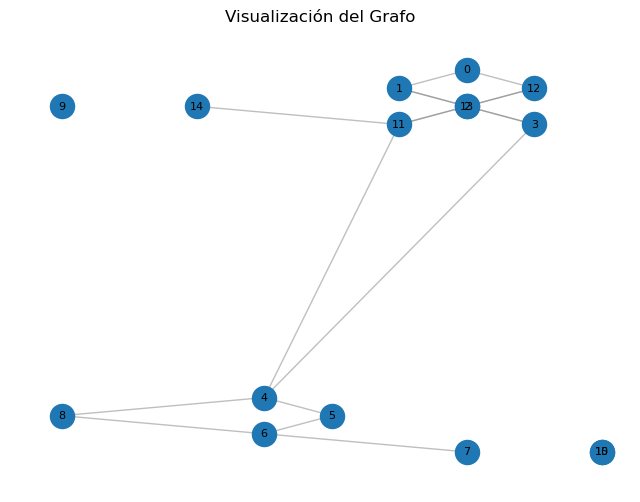

In [191]:
#Ejemplo para ver como se han creado los grafos
n=0
grafo  = crear_grafo_con_posiciones(df_digis_nodos.iloc[n], df_segments_nodos.iloc[n], imprimir_nodos=True, ruido=True)
edge_index = grafo.edge_index
aristas = edge_index

print(grafo)
print('nodos:', grafo.x)
print("Aristas: \n", aristas)
print('Verdad nodos', grafo.y)
print('atributo aristas:', grafo.edge_attr)

dibujar_grafo(grafo)

# Dataset

In [192]:
from torch.utils.data import Dataset
from sklearn.preprocessing import StandardScaler
import torch
from torch_geometric.data import Data, Dataset

class GrafoDataset(Dataset):
    def __init__(self, data_rows, data_verdad, normalize=True):
        self.data_rows = data_rows
        self.data_verdad = data_verdad
        self.normalize = normalize  
        
        if self.normalize:
            self.scaler = StandardScaler()
            all_positions = self.obtener_todas_las_posiciones()
            self.scaler.fit(all_positions) 

    def __len__(self):
        return len(self.data_rows)

    def __getitem__(self, idx):
        row = self.data_rows[idx]
        row_verdad = self.data_verdad[idx]
        
        # Crear el grafo con posiciones
        data = crear_grafo_con_posiciones(row, row_verdad)
        
        # Normalizar las posiciones
        if self.normalize:
            data.x = self.normalizar_posiciones(data.x)
            
        if self.normalize and data.edge_attr is not None:
            data.edge_attr = self.normalizar_atributos(data.edge_attr)
        
        return data

    def obtener_todas_las_posiciones(self):
        # Extrae todas las posiciones de los nodos en un solo array
        posiciones = []
        for idx, row in enumerate(self.data_rows):
            data = crear_grafo_con_posiciones(row, self.data_verdad[idx]) 
            posiciones.append(data.x.numpy())  
        
        return np.vstack(posiciones)  # Unimos todas las posiciones en una sola matriz

    def normalizar_posiciones(self, x):
        pos = x.numpy() 
        pos_norm = self.scaler.transform(pos) 
        return torch.tensor(pos_norm, dtype=torch.float)

class GrafoDataset(Dataset):
    def __init__(self, data_rows, data_verdad, normalize=True, ruido = False):
        self.data_rows = data_rows
        self.data_verdad = data_verdad
        self.normalize = normalize  
        self.ruido = ruido

        
        if self.normalize:
            self.scaler = StandardScaler()
            all_positions = self.obtener_todas_las_posiciones()
            self.scaler.fit(all_positions)  

            # Nuevo scaler para edge_attr
            self.edge_scaler = StandardScaler()
            all_edges = self.obtener_todos_los_atributos()
            if all_edges.shape[0] > 0:  # Evitar error si está vacío
                self.edge_scaler.fit(all_edges)

    def __len__(self):
        return len(self.data_rows)

    def __getitem__(self, idx):
        row = self.data_rows[idx]
        row_verdad = self.data_verdad[idx]
        
        data = crear_grafo_con_posiciones(row, row_verdad, ruido=self.ruido)
        
        if self.normalize and data.x is not None:
            data.x = self.normalizar_posiciones(data.x)
            
        if self.normalize and data.edge_attr is not None and data.edge_attr.numel() > 0:
            data.edge_attr = self.normalizar_atributos(data.edge_attr)
        
        return data

    def obtener_todas_las_posiciones(self):
        posiciones = []
        for idx, row in enumerate(self.data_rows):
            data = crear_grafo_con_posiciones(row, self.data_verdad[idx], ruido=self.ruido) 
            if data.x is not None:
                posiciones.append(data.x.detach().cpu().numpy())  
        return np.vstack(posiciones) if posiciones else np.empty((0,)) 

    def obtener_todos_los_atributos(self):
        atributos = []
        for idx, row in enumerate(self.data_rows):
            data = crear_grafo_con_posiciones(row, self.data_verdad[idx], ruido=self.ruido) 
            if data.edge_attr is not None and data.edge_attr.numel() > 0:
                atributos.append(data.edge_attr.detach().cpu().numpy())  
        return np.vstack(atributos) if atributos else np.empty((0,)) 

    def normalizar_posiciones(self, x):
        pos = x.detach().cpu().numpy() 
        pos_norm = self.scaler.transform(pos) 
        return torch.tensor(pos_norm, dtype=torch.float, device=x.device)
    
    def normalizar_atributos(self, edge_attr):
        if edge_attr is None or edge_attr.numel() == 0:
            return edge_attr
        attr = edge_attr.detach().cpu().numpy()
        attr_norm = self.edge_scaler.transform(attr)  # Usar el scaler de edge_attr
        return torch.tensor(attr_norm, dtype=torch.float, device=edge_attr.device)


# dataset
df_digis_train = df_digis_nodos.sample(frac=0.8, random_state=42)  # 80% para entrenamiento
df_digis_val = df_digis_nodos.drop(df_digis_train.index)  # 20% restante para validación/test
df_digis_train_lista = df_digis_train .to_dict('records')
df_digis_val_lista = df_digis_val.to_dict('records')

df_segments_train = df_segments_nodos.loc[df_digis_train.index]  # Misma selección
df_segments_val = df_segments_nodos.loc[df_digis_val.index]  # Misma selección
df_segments_train_lista = df_segments_train.to_dict('records')
df_segments_val_lista = df_segments_val.to_dict('records')

# Ejemplo de uso con un dataset:
train_dataset = GrafoDataset(df_digis_train_lista , df_segments_train_lista , normalize=True, ruido = True)
val_dataset = GrafoDataset(df_digis_val_lista, df_segments_val_lista, normalize=True, ruido = False)


In [193]:
# Prueba
print(f"Tamaño del dataset: {len(train_dataset)}")
i = 0
ejemplo = train_dataset[i]
print(f'Ejemplo grafo {i}:', ejemplo)
print('Numero de nodos:' , ejemplo.num_nodes)
print('Nodos:', ejemplo.x)
print('Numero de aristas:', ejemplo.num_edges)
print('Aristas:', ejemplo.edge_index)
print('atributos aristas:', ejemplo.edge_attr)
print(f'Verdad: {ejemplo.y}')

Tamaño del dataset: 1831
Ejemplo grafo 0: Data(x=[18, 6], edge_index=[2, 26], edge_attr=[26, 5], y=[18])
Numero de nodos: 18
Nodos: tensor([[ 1.1216,  1.1505, -0.9924,  1.4558, -1.3423, -0.8145],
        [ 1.1586,  1.0407, -0.9924,  1.5274, -0.4480,  0.0961],
        [ 1.1216,  0.9309, -0.9924,  1.4558,  0.4463,  0.0891],
        [ 1.2327,  0.8212, -0.9924,  1.5274,  1.3406, -0.8425],
        [ 1.1957, -0.8340,  1.0076,  1.4558, -1.3423,  0.5515],
        [ 1.2697, -0.8340,  1.0076,  1.5274, -1.3423,  0.0611],
        [ 1.2327, -0.9438,  1.0076,  1.5274, -0.4480, -1.1998],
        [ 1.2327, -0.9438,  1.0076,  1.5274, -0.4480,  0.3904],
        [ 1.1957, -1.0535,  1.0076,  1.4558,  0.4463,  1.4131],
        [ 1.3068, -1.1633,  1.0076,  1.5274,  1.3406, -1.5920],
        [ 0.9734,  0.9309, -0.9924,  1.3126,  0.4463,  0.0954],
        [ 1.2697, -1.0535,  1.0076,  1.5274,  0.4463, -1.5916],
        [ 1.1216, -0.8340,  1.0076,  1.3842, -1.3423,  0.5511],
        [ 1.3438,  1.1505, -0.9924, 

## Grafica de datos

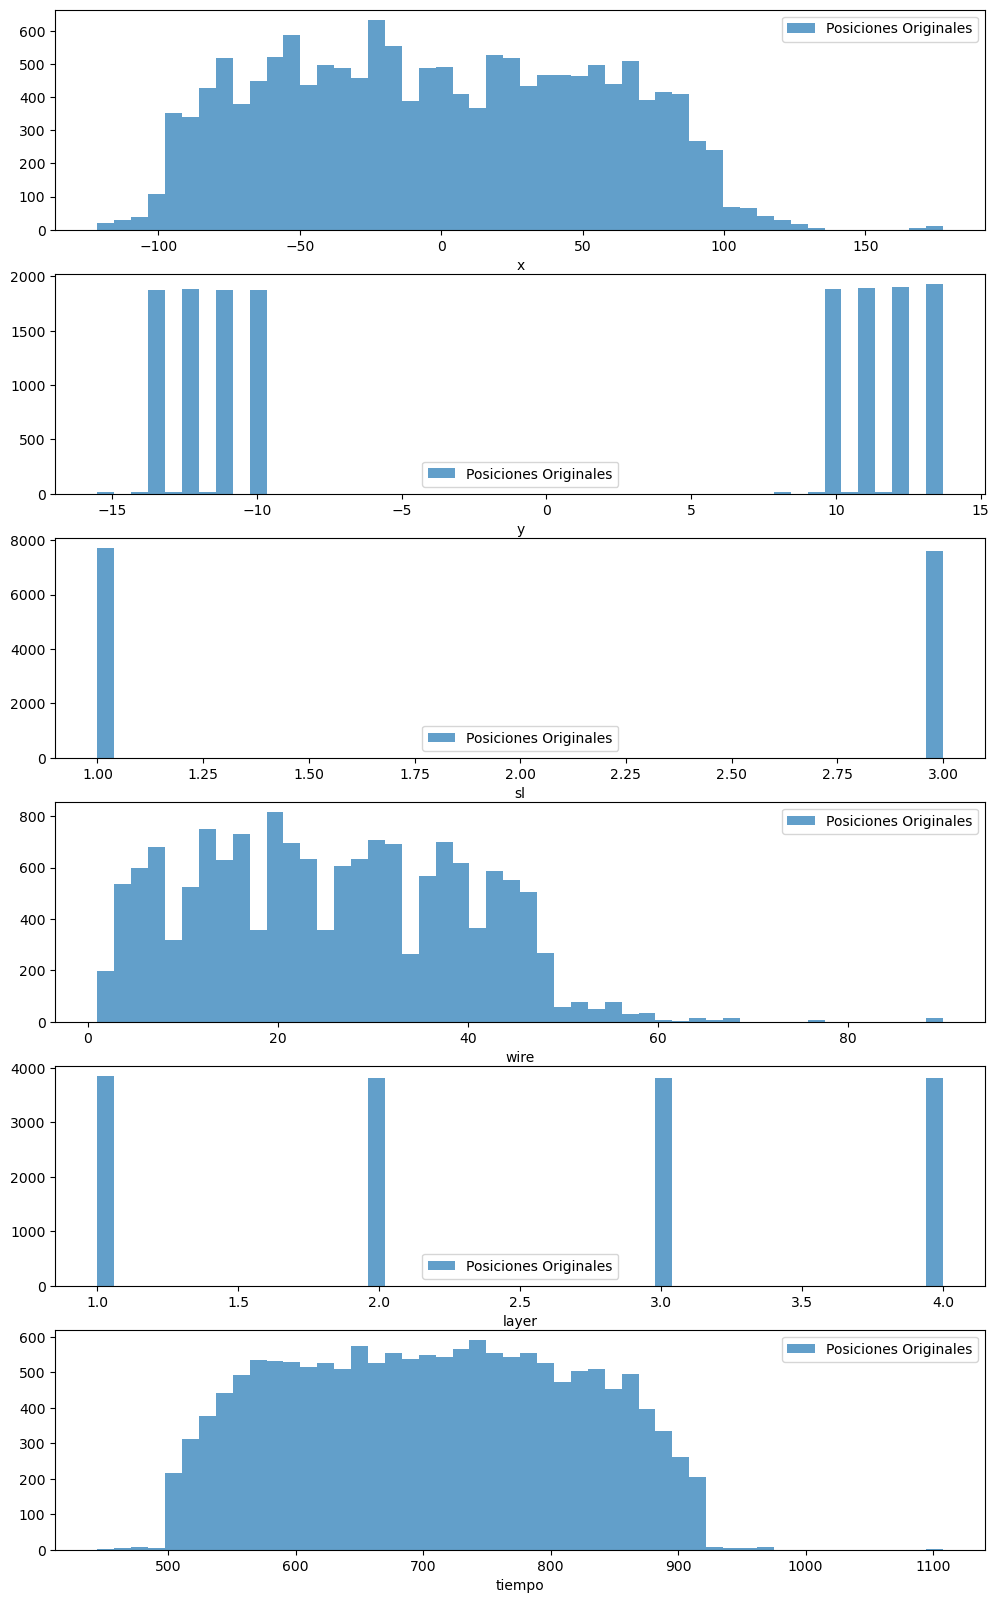

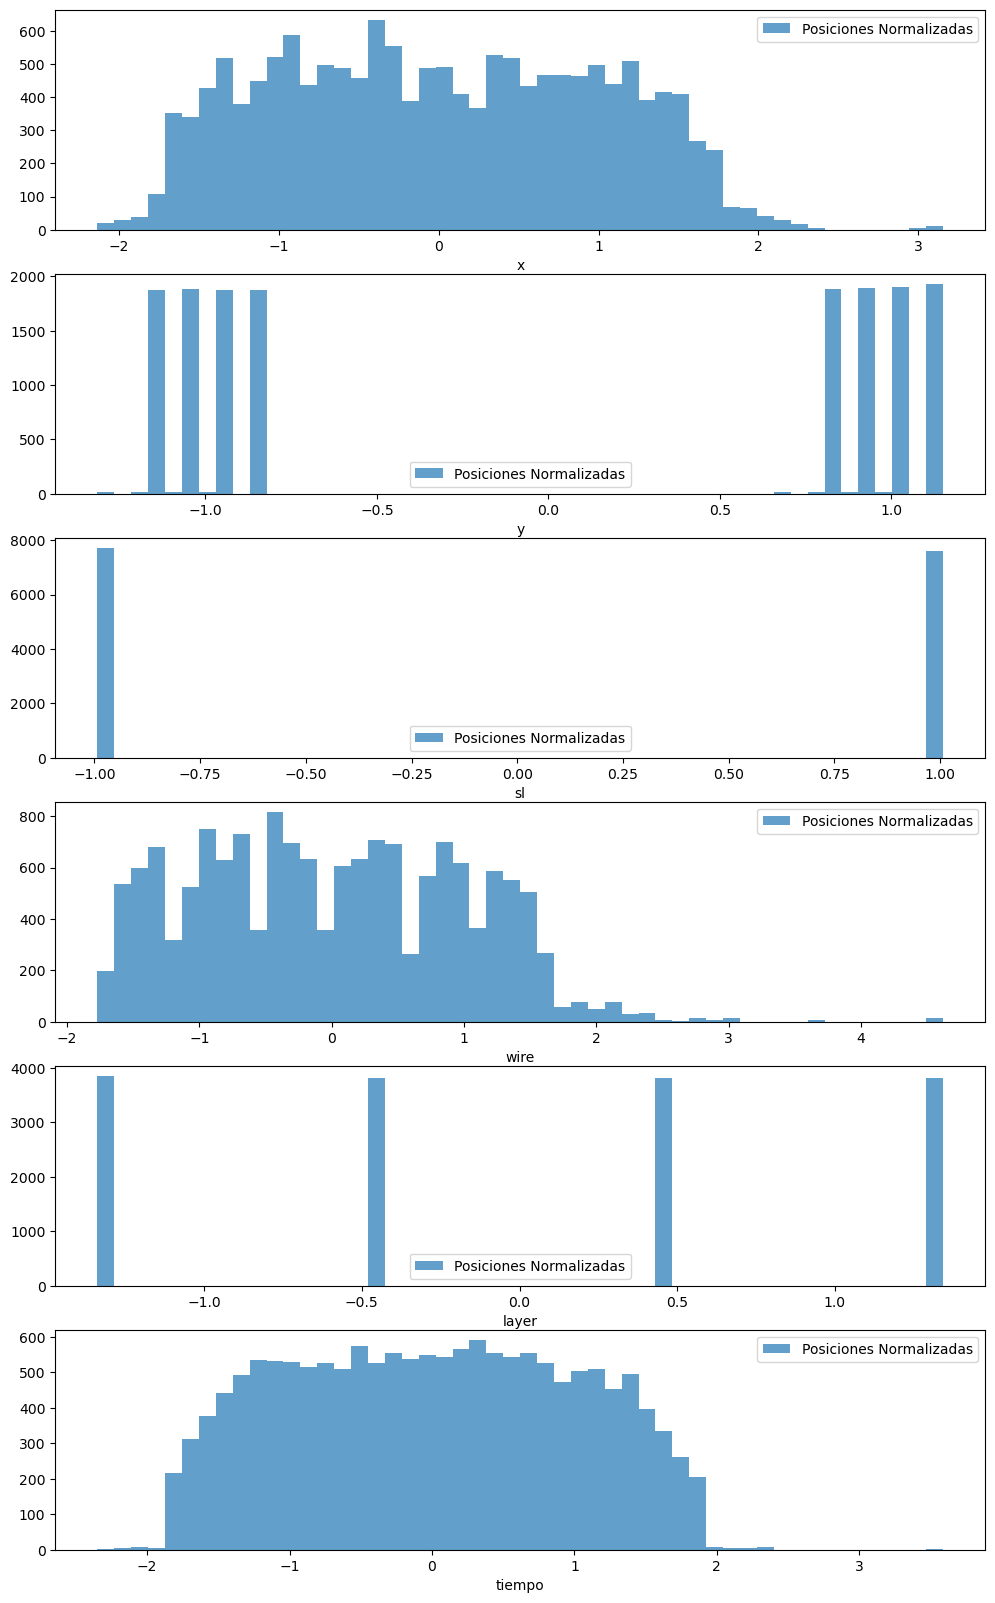

In [24]:
import matplotlib.pyplot as plt
import networkx as nx

def graficar_histograma(dataset, normalizado=True):
    """ Grafica histogramas de las posiciones de los nodos antes y después de la normalización """
    posiciones = dataset.obtener_todas_las_posiciones()
    aristas = dataset.obtener_todos_los_atributos()
    
    if posiciones.shape[0] == 0:
        print("No hay posiciones para graficar.")
        return
    
    # Si queremos las posiciones normalizadas
    if normalizado:
        posiciones = dataset.scaler.transform(posiciones)
        aristas = dataset.edge_scaler.transform(aristas)

    fig, axes = plt.subplots(6 ,1 , figsize=(12, 20))  # Cambia el tamaño con figsize=(ancho, alto)

    axes[0].hist(posiciones[:, 0], bins=50, alpha=0.7, label="Posiciones Normalizadas" if normalizado else "Posiciones Originales")
    axes[0].set_xlabel("x")
    axes[0].legend()

    axes[1].hist(posiciones[:, 1], bins=50, alpha=0.7, label="Posiciones Normalizadas" if normalizado else "Posiciones Originales")
    axes[1].set_xlabel("y")
    axes[1].legend()

    axes[2].hist(posiciones[:, 2], bins=50, alpha=0.7, label="Posiciones Normalizadas" if normalizado else "Posiciones Originales")
    axes[2].set_xlabel("sl")
    axes[2].legend()

    axes[3].hist(posiciones[:, 3], bins=50, alpha=0.7, label="Posiciones Normalizadas" if normalizado else "Posiciones Originales")
    axes[3].set_xlabel("wire")
    axes[3].legend()

    axes[4].hist(posiciones[:, 4], bins=50, alpha=0.7, label="Posiciones Normalizadas" if normalizado else "Posiciones Originales")
    axes[4].set_xlabel("layer")
    axes[4].legend()

    axes[5].hist(posiciones[:, 5], bins=50, alpha=0.7, label="Posiciones Normalizadas" if normalizado else "Posiciones Originales")
    axes[5].set_xlabel("tiempo")
    axes[5].legend()

    '''axes[0].hist(aristas[:, 0], bins=50, alpha=0.7, label="Aristas Normalizadas" if normalizado else "Aristas Originales")
    axes[0].set_xlabel("distancias")
    axes[0].legend()

    axes[1].hist(aristas[:, 1], bins=50, alpha=0.7, label="Aristas Normalizadas" if normalizado else "Aristas Originales")
    axes[1].set_xlabel("diferencias sl3")
    axes[1].legend()'''

    plt.show() 
    return posiciones, aristas


# Ejemplo de uso con un dataset:
dataset = GrafoDataset(df_digis_train_lista, df_segments_train_lista, normalize=True)

# Histogramas antes y después de la normalización
posiciones, aristas = graficar_histograma(dataset, normalizado=False)
posiciones_norm, aristas_nom = graficar_histograma(dataset, normalizado=True)



# GNN

In [194]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv, SAGEConv
from torch.nn import Dropout
      
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = GATConv(hidden_channels, out_channels, heads=1, concat=False)
        self.dropout = torch.nn.Dropout(p=0.5)  

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.dropout(x)  # Dropout en la capa oculta
        x = self.conv2(x, edge_index)
        return x # Para clasificacion binaria

class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, edge_attr_dim, heads=6, dropout=0.5):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = GATConv(hidden_channels, hidden_channels, edge_dim=edge_attr_dim, heads=heads, concat=True)
        self.conv3 = SAGEConv(hidden_channels * heads, hidden_channels)  # Multiplicamos por heads porque concat=True
        self.conv4 = GATConv(hidden_channels, out_channels, edge_dim=edge_attr_dim, heads=1, concat=False)

    def forward(self, x, edge_index, edge_attr):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        #x = self.dropout(x)

        x = self.conv2(x, edge_index, edge_attr)
        x = F.relu(x)
        #x = self.dropout(x)
        x = self.conv3(x, edge_index)
        x = F.relu(x)

        x = self.conv4(x, edge_index, edge_attr)  
        return x  # Para clasificacion binaria

# Seleccionar GPU si no esta disponible pues CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')  # 'cuda' o 'cpu'

Device: cpu


# Train y tests dataset y dataloaders

In [195]:
from torch_geometric.loader import DataLoader
from sklearn.model_selection import train_test_split

# Dividir entre train y (validación + test)
validation_dataset, test_dataset = train_test_split(val_dataset, test_size=0.5, random_state=42)

# Comprobamos el tamaño
print(f'Tamaño de los datasets: train = {len(train_dataset)},validation = {len(validation_dataset)}, test = {len(test_dataset)}' )

# De momento vamos a filtrar los Nans y ya veremos de donde vienen
def filtrar_nans(dataset):
    filtered_dataset = []
    dataset_con_nans =[]
    for i , data in enumerate(dataset):
        if torch.isnan(data.x).sum() == 0 and torch.isnan(data.y).sum() == 0:
            filtered_dataset.append(data)
        else:
            dataset_con_nans.append(data)
            #print(f'Datos con nans: indice = {i}')
            #print('dato = {data} \n nodos: {data.x} \n aristas: {data.y}')
    return filtered_dataset, dataset_con_nans

train_dataset, dataset_nans_train = filtrar_nans(train_dataset)
validation_dataset, dataset_nans_validation = filtrar_nans(validation_dataset)
test_dataset, dataset_nans_test = filtrar_nans(test_dataset)
# Comprobamos el tamaño
print(f'Tamaño de la parte del dataset con nans: train = {len(dataset_nans_train)}, validation = {len(dataset_nans_validation)}, test = {len(dataset_nans_test)}')
print(f'Tamaño de los datasets despues del fltrado: train = {len(train_dataset)}, validation = {len(validation_dataset)}, test = {len(test_dataset)}' )

# Creamos DataLoaders
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=1, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

Tamaño de los datasets: train = 1831,validation = 229, test = 229
Tamaño de la parte del dataset con nans: train = 74, validation = 2, test = 1
Tamaño de los datasets despues del fltrado: train = 1757, validation = 227, test = 228


# Entrenamiento

## Definiciones

### focalloss

In [196]:
from torch import nn
# FOCAL LOSS
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.25):
        """
        Focal Loss para clasificación binaria.

        Args:
        - gamma (float): Controla cuánto más duro se penalizan los ejemplos mal clasificados.
        - alpha (float): Ajusta el peso de las muestras positivas frente a las negativas.
        """
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, preds, targets):
        """
        Calcula la focal loss.
        
        Args:
        - preds: Predicciones del modelo (logits antes de aplicar la función sigmoid).
        - targets: Etiquetas reales binarias (0 para ruido, 1 para segmento).
        
        Returns:
        - Valor de la pérdida.
        """
        preds = preds.view(-1)  # Aplana las predicciones
        targets = targets.view(-1)  # Aplana las etiquetas reales
        
        # Calcula la BCE estándar
        bce_loss = F.binary_cross_entropy_with_logits(preds, targets, reduction="none")
        
        # Calcula la probabilidad de predicción correcta
        pt = torch.exp(-bce_loss)  # pt = P(y=1) para predicciones correctas
        
        # Aplica el peso de la focal loss
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        
        return focal_loss.mean()


### Resto de defs

In [207]:
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, f1_score

# Defino el modelo
# Parametros
input_dim = 6   # x, y positions
hidden_dim = 20
output_dim = 2  # Numero de clases (nodo verdad 1 o no 0)
edge_attr_dim = 5

#model = GCN_2(input_dim, hidden_dim, output_dim, edge_attr_dim)
model = GCN(input_dim, hidden_dim, 1, edge_attr_dim) #output = 1 por el focalloss
lr, weight_decay = 0.01, 1e-5
optimizer = torch.optim.Adam(model.parameters(), lr = lr, weight_decay = weight_decay) 
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5, factor=0.3, verbose=True)

# perdida
#pos_weight = torch.tensor([0.15])  # Ajusta el peso
pos_weight = None
#loss_fn = torch.nn.BCEWithLogitsLoss()
gamma, alpha = 2, 0.9
loss_fn = FocalLoss(gamma, alpha)  # Focal Loss con balanceo de clases
#loss_fn = nn.CrossEntropyLoss(weight = class_weights)

def plot_confusion(all_preds,all_labels,epoch):
    # matriz de confusion y el F1-score
    cm = confusion_matrix(all_labels, all_preds)
    print(classification_report(all_labels, all_preds, target_names=["Clase 0", "Clase 1"]))

    # Plot
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(all_labels), yticklabels=np.unique(all_labels))
    plt.title(f'Matriz de Confusion - Epoch {epoch + 1}')
    plt.xlabel('Predicciones')
    plt.ylabel('Verdadero')
    plt.show()

def generar_malas_predicciones(preds, labels, malas_predicciones):
    # lista para ver si hay alguna relacion entre las malas predicciones y el nodo 
    for node_idx in range(len(preds)):  
        if preds[node_idx][0] != labels[node_idx][0]:  # Si la prediccion es incorrecta
            malas_predicciones.append({
                'data': data,
                'node_idx': node_idx,
                'nodo': data.x[node_idx],
                'prediccion': preds[node_idx],
                'real_label': labels[node_idx]
            })


threshold = 0.5 #supongo q es 0.5?
def train(data, loss_fn):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index, data.edge_attr)# Forward pass
    loss = loss_fn(out, data.y) # Calcular perdida
    loss.backward()
    optimizer.step()
    preds = out.argmax(dim=1).cpu().numpy()  # Predicciones
    preds =(torch.sigmoid(out) > threshold).float() # lo convierto a float para q no sea true/false
    labels = data.y.cpu().numpy()  # Etiquetas verdaderas
    return loss, preds, labels

def evaluacion(data):
    model.eval()
    data = data.to(device)
    logits = model(data.x, data.edge_index, data.edge_attr)
    loss = loss_fn(logits, data.y)
    preds = torch.argmax(logits, dim=1)
    preds = (torch.sigmoid(logits) > threshold).float()
    return loss, preds, logits


/home/blanca_belmonte/miniconda3/envs/jupyter_ml_env/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


## Main

Epoch 1/23, Train Loss: 0.0705, Validation Loss: 0.1085, Validation accuracy: 0.8993
Epoch 2/23, Train Loss: 0.0581, Validation Loss: 0.0459, Validation accuracy: 0.9948
Epoch 3/23, Train Loss: 0.0598, Validation Loss: 0.0536, Validation accuracy: 0.9948
Epoch 4/23, Train Loss: 0.0592, Validation Loss: 0.0601, Validation accuracy: 0.9940
Epoch 5/23, Train Loss: 0.0568, Validation Loss: 0.0393, Validation accuracy: 0.9948
              precision    recall  f1-score   support

     Clase 0       1.00      0.79      0.88     14473
     Clase 1       0.82      1.00      0.90     14056

    accuracy                           0.89     28529
   macro avg       0.91      0.90      0.89     28529
weighted avg       0.91      0.89      0.89     28529



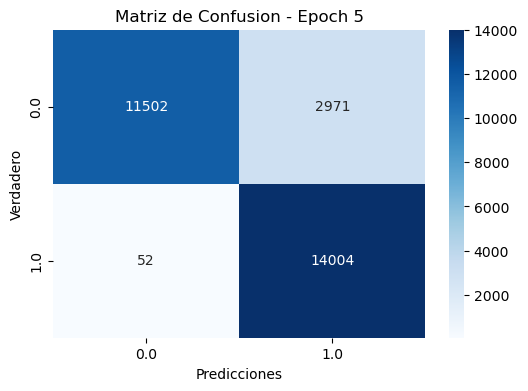

Epoch 6/23, Train Loss: 0.0504, Validation Loss: 0.0394, Validation accuracy: 0.9948


KeyboardInterrupt: 

In [208]:
# epocas
epochs = 23

# para hacer las curvas de aprendizaje necesito almacenar las perdidas y precision
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
malas_predicciones=[]

# entrenamiento
for epoch in range(epochs):
    epoch_loss = 0
    all_preds = []  # almacenar las predicciones
    all_labels = []  # almacenar las etiquetas verdaderas

    for data in train_loader:
        # Verificar si el grafo tiene aristas
        if data.edge_index.numel() == 0:  
            continue 

        data.y = data.y.float()  
        data.y = data.y.view(-1, 1)  # la salida del modelo es tipo (batch_size, 1), pero data.y tiene forma (batch_size), asi q lo cambio
        loss, preds, labels = train(data, loss_fn)
        epoch_loss += loss.item()
        all_preds.extend(preds)
        all_labels.extend(labels)
        
        # CONFIDENCE SCORE en la ultima epoca
        if epoch == epochs-1:          
            generar_malas_predicciones(preds, labels, malas_predicciones)
    scheduler.step(epoch_loss)
    train_losses.append(epoch_loss/len(train_loader))
    train_accuracies.append(f1_score(all_labels, all_preds))

    #evaluar modelo
    val_loss = 0
    all_preds_val = []
    all_labels_val = []
    with torch.no_grad():
        for data in validation_loader:
            if data.edge_index.numel() == 0:  
                continue 
            data.y = data.y.float()
            data.y = data.y.view(-1, 1) 
            loss, preds, logits = evaluacion(data)
            val_loss += loss.item()
            all_preds_val.append(preds.cpu())
            all_labels_val.append(data.y.cpu())  

    val_losses.append(val_loss/len(validation_loader))
    all_preds_val = torch.cat(all_preds_val).numpy()
    all_labels_val = torch.cat(all_labels_val).numpy()
    val_accuracies.append(f1_score(all_labels_val, all_preds_val))
    
    print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {epoch_loss/len(train_loader):.4f}, Validation Loss: {val_loss/len(validation_loader):.4f}, Validation accuracy: {f1_score(all_labels_val, all_preds_val):.4f}")
    if (epoch+1)%5==0:
        plot_confusion(all_preds, all_labels, epoch)


              precision    recall  f1-score   support

     Clase 0       0.99      0.87      0.93     14473
     Clase 1       0.88      0.99      0.93     14056

    accuracy                           0.93     28529
   macro avg       0.94      0.93      0.93     28529
weighted avg       0.94      0.93      0.93     28529



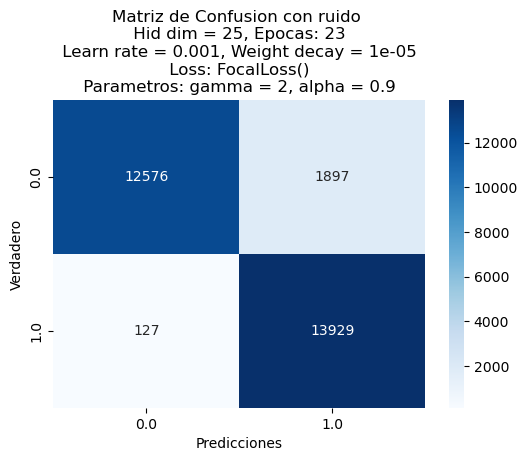

In [199]:
cm = confusion_matrix(all_labels, all_preds)
print(classification_report(all_labels, all_preds, target_names=["Clase 0", "Clase 1"]))
# Obtener parámetros según la función de pérdida utilizada
if isinstance(loss_fn, FocalLoss):
    parametros = f'gamma = {loss_fn.gamma}, alpha = {loss_fn.alpha}'
    param=f'g{loss_fn.gamma}_alp{loss_fn.alpha}'
elif isinstance(loss_fn, nn.BCEWithLogitsLoss):
    parametros = f'pos_weight = {pos_weight}'
    param = f'posw{pos_weight}'
else:
    parametros =  None

# Plot
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(all_labels), yticklabels=np.unique(all_labels))
parametros = f'gamma = {loss_fn.gamma}, alpha = {loss_fn.alpha}' if isinstance(loss_fn, FocalLoss) else f'pos_weight = {pos_weight}'
plt.title(f'Matriz de Confusion con ruido \n Hid dim = {hidden_dim}, Epocas: {epoch + 1} \n Learn rate = {lr}, Weight decay = {weight_decay} \n Loss: {loss_fn} \n Parametros: {parametros} ')
plt.xlabel('Predicciones')
plt.ylabel('Verdadero')
nombre_archivo = f'distancias_bien_hd{hidden_dim}_ep{epoch+1}_lr{lr}_wd{weight_decay}_{loss_fn}_param{param}.png'
#plt.savefig(nombre_archivo, bbox_inches='tight')
plt.show()


Indice 70:
x (nodos): tensor([[ 1.0061,  1.1505, -0.9924,  0.8830, -1.3423, -0.4853],
        [ 1.0431,  1.0407, -0.9924,  0.9546, -0.4480,  0.1102],
        [ 1.0061,  0.9309, -0.9924,  0.8830,  0.4463,  0.0331],
        [ 1.1172,  0.8212, -0.9924,  0.9546,  1.3406, -0.3241],
        [ 1.0431, -0.8340,  1.0076,  0.9546, -1.3423,  0.2503],
        [ 1.0801, -0.9438,  1.0076,  1.0262, -0.4480, -0.5623],
        [ 1.0431, -1.0535,  1.0076,  0.9546,  0.4463,  0.6776],
        [ 1.1542, -1.1633,  1.0076,  1.0262,  1.3406, -1.0527],
        [ 1.1542,  0.9309, -0.9924,  1.0262,  0.4463, -1.0524],
        [ 1.0431, -1.0535,  1.0076,  0.9546,  0.4463,  0.0333],
        [ 0.8950,  1.0407, -0.9924,  0.8114, -0.4480, -1.0533],
        [ 0.8209,  1.0407, -0.9924,  0.7398, -0.4480,  0.2503],
        [ 0.9320,  1.1505, -0.9924,  0.8114, -1.3423,  0.0331],
        [ 0.9320,  0.9309, -0.9924,  0.8114,  0.4463,  0.6770],
        [ 1.2283,  1.1505, -0.9924,  1.0978, -1.3423,  0.0332],
        [ 1.1172, 

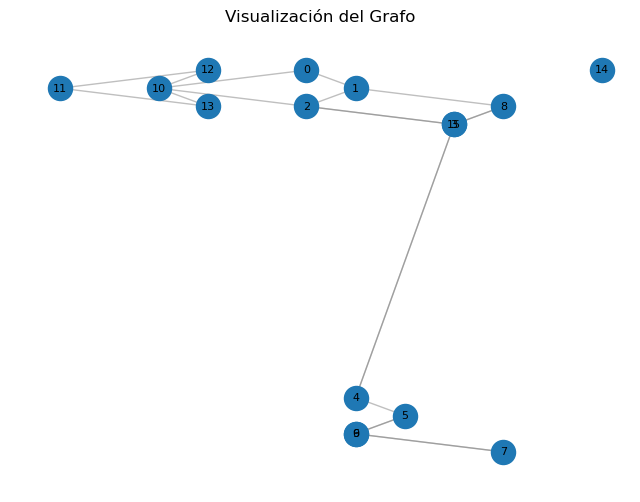

In [200]:
# Visualizar un lote de datos para ver que esta pasando
df_malas_predicciones = pd.DataFrame(malas_predicciones)

def ver_datos(df, i=0):
    #n es el numero de grafos que quieres ver
    dato = df.iloc[i]['data']
    prediccion = df.iloc[i]['prediccion']
    etiqueta_real = df.iloc[i]['real_label']
    nodo_mal_etiquetado = df.iloc[i]['node_idx']

    print(f"Indice {i}:")
    print(f"x (nodos): {dato.x}")
    print(f"y (verdades): {dato.y}")
    print(f"aristas: {dato.edge_index}")
    print(f"El nodo que esta mal etiquetado: {nodo_mal_etiquetado}")
    print(f"Prediccion: {prediccion}")
    print(f"Etiqueta real: {etiqueta_real}")

n = 70

ver_datos(df_malas_predicciones, n)
dibujar_grafo(df_malas_predicciones.iloc[n]['data'])

# Curvas aprendizaje

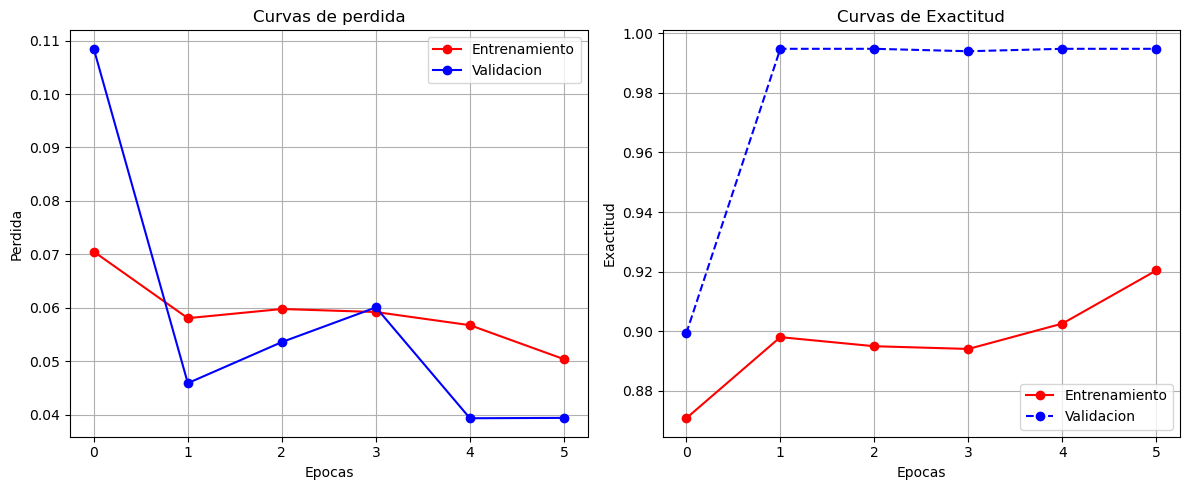

In [209]:
fig, ax = plt.subplots(1,2, figsize=(12, 5))
ax[0].plot(train_losses, 'o-', color='red',label='Entrenamiento')
ax[0].plot(val_losses, 'o-', color='blue',label='Validacion')
ax[0].set_xlabel('Epocas')
ax[0].set_ylabel('Perdida')
ax[0].set_title('Curvas de perdida')
ax[0].grid()
ax[0].legend()

ax[1].plot(train_accuracies, 'o-', color='red', label = 'Entrenamiento')
ax[1].plot(val_accuracies, 'o--', color='blue',label = 'Validacion')
ax[1].set_xlabel('Epocas')
ax[1].set_ylabel('Exactitud')
ax[1].set_title('Curvas de Exactitud')
ax[1].grid()
ax[1].legend()
plt.tight_layout()
plt.show()

# Test

              precision    recall  f1-score   support

     Clase 0       1.00      0.37      0.54        43
     Clase 1       0.99      1.00      0.99      1824

    accuracy                           0.99      1867
   macro avg       0.99      0.69      0.77      1867
weighted avg       0.99      0.99      0.98      1867



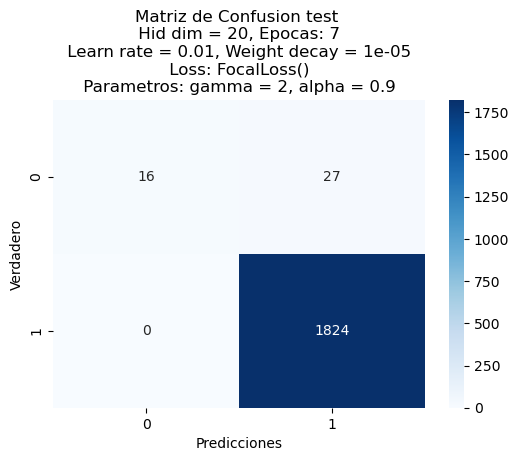

In [210]:
import torch
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluar_modelo(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []
   
    with torch.no_grad(): # Desactivar gradientes
        for data in dataloader:
            if data.edge_index.numel() == 0:
                print(data)  
                continue 
            data = data.to(device)
            logits = model(data.x, data.edge_index, data.edge_attr)
            preds = torch.argmax(logits, dim=1)
            threshold = 0.5
            preds = (torch.sigmoid(logits) > threshold).float()
            all_preds.append(preds.cpu())
            all_labels.append(data.y.cpu())
    
    # Concatenar predicciones y etiquetas reales
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)
    
    # Calcular matriz de confusion y el report
    cm = confusion_matrix(all_labels, all_preds)
    report = classification_report(all_labels, all_preds, target_names=["Clase 0", "Clase 1"])
    nombre_archivo = f'test_hd{hidden_dim}_ep{epoch+1}_lr{lr}_wd{weight_decay}_{loss_fn}_param{param}.png'
    with open(f"classification_report_{nombre_archivo}.txt", "w") as f: # guardo el report en un txt
        f.write(report)
    print(report)

    # Plot
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(all_labels), yticklabels=np.unique(all_labels))
    plt.title(f'Matriz de Confusion test \n Hid dim = {hidden_dim}, Epocas: {epoch + 1} \n Learn rate = {lr}, Weight decay = {weight_decay} \n Loss: {loss_fn} \n Parametros: {parametros} ')
    plt.xlabel('Predicciones')
    plt.ylabel('Verdadero')
    plt.savefig(nombre_archivo, bbox_inches='tight')
    plt.show()

evaluar_modelo(model, test_loader, device)

# ROC, AUC, precision recall

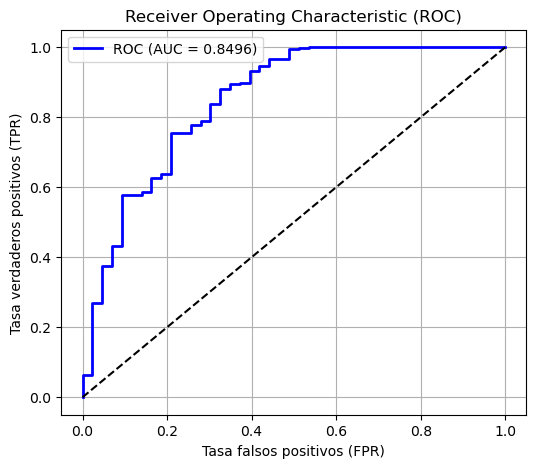

In [203]:
from sklearn.metrics import roc_curve, auc
def probs_labels(model, dataloader, device):
    all_probs = []  # Probabilidades para la clase positiva
    all_labels = []  # Etiquetas verdaderas

    model.eval()
    with torch.no_grad():
        for data in dataloader:
            if data.edge_index.numel() == 0:  
                continue 
            data.y = data.y.float()
            data.y = data.y.view(-1, 1) 
            out = model(data.x, data.edge_index, data.edge_attr)
            probs = torch.sigmoid(out).cpu().numpy().flatten()  # Correcto para output_dim=1
            labels = data.y.cpu().numpy()

            all_probs.extend(probs.tolist()) 
            all_labels.extend(labels.tolist()) 
    return all_probs, all_labels

def roc_y_auc(all_probs, all_labels):
    FPR, TPR, _ = roc_curve(all_labels, all_probs) #tasa falsos positivos y tasa verdaderos positivos
    roc_auc = auc(FPR, TPR) #area bajo la ROC

    plt.figure(figsize = (6,5))
    plt.plot(FPR, TPR, color ='b', lw=2, label = f'ROC (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], 'k--')  # Linea diagonal
    plt.xlabel('Tasa falsos positivos (FPR)')
    plt.ylabel('Tasa verdaderos positivos (TPR)')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.grid()
    plt.legend()
    plt.show()

all_probs, all_labels = probs_labels(model, test_loader, device)
roc_y_auc(all_probs, all_labels)

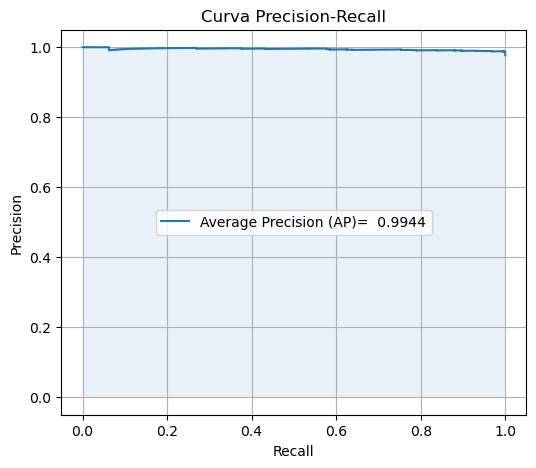

In [204]:
from sklearn.metrics import precision_recall_curve, average_precision_score

def precision_recall(all_labels, all_probs):
    precision, recall, _ = precision_recall_curve(all_labels, all_probs)
    average_precision = average_precision_score(all_labels, all_probs)

    plt.figure(figsize = (6,5))
    plt.step(recall, precision, where = 'post', label = f'Average Precision (AP)= {average_precision: .4f}')
    plt.fill_between(recall, precision, step='post', alpha = 0.1)
    plt.title('Curva Precision-Recall')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.legend()
    plt.grid()
    plt.show()

precision_recall(all_labels,all_probs)
